# [이론] 군집화 · 차원축소

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🧭 군집화와 차원축소 — 정답 없이 구조를 찾는다

## — 정답(레이블) 없는 데이터에서 숨은 그룹을 찾고, 많은 열을 눈으로 볼 수 있게 줄입니다

---

## 📋 학습 목표

이 학습 노트북을 마치면 여러분은 다음을 할 수 있습니다.

1. **지도학습과 비지도학습의 차이**를 설명하고, **K-Means·DBSCAN**의 원리와 *적합한 데이터 형태*를 비교합니다.
2. **Elbow·Silhouette**이 서로 다른 군집 품질을 재며, 어느 지표도 정답을 보장하지 않음을 설명합니다.
3. **K-Means로 고객 데이터를 군집화**하고 Silhouette·Elbow로 적정 군집 수를 정합니다.
4. **세그먼트별 특성을 분석해 비즈니스 의미로 해석**합니다.
5. **PCA 2차원 투영의 설명 분산비**를 읽고 시각화의 손실을 설명합니다.
6. 군집에서 만든 **중심거리 피처**를 `Pipeline` 안에서 평가하고, 전체 데이터 `fit`이 왜 누수인지 설명합니다.
7. 정답이 없는 결과를 **비즈니스 가설로 번역하고 추가 검증**하는 태도를 가집니다.

> 💡 **한 문장 요약:**  
> 지금까지는 _정답을 보고 배웠지만_, 오늘은 **정답 없이 데이터 스스로 그룹을 찾게** 합니다.

_💡 위 목록을 천천히 읽고, 지금 할 수 있는 것과 아직 낯선 것을 마음속으로 표시해 봅시다. 노트북을 마친 뒤 다시 돌아와 비교하면 성장이 눈에 보일 것입니다._

## 📚 학습 목차

| Part | 내용                                   | 핵심 질문                                  | 예상 시간 |
| ---- | -------------------------------------- | ------------------------------------------ | --------- |
| 0    | 오늘의 여정                            | 정답이 없는 데이터는 어떻게 다루나?        | 20분      |
| 1    | 지도학습 vs 비지도학습                 | 정답이 없다는 것이 무엇을 바꾸나?          | 15분      |
| 2    | K-Means — 중심으로 그룹을 나눈다       | 컴퓨터는 어떻게 '비슷한 것'을 묶나?        | 35분      |
| 3    | 군집 수(k) 결정                        | 몇 개로 나눠야 하는지 누가 정하나?         | 50분      |
| 4    | DBSCAN — 밀도로 가른다                 | K-Means가 못 푸는 모양이 있나?             | 10분      |
| 5    | 차원축소 — 많은 피처를 눈으로 보기     | 열세 개의 열을 두 개로 누르면 무엇을 잃나? | 35분      |
| 6    | 세그먼트 해석 — 군집을 비즈니스 의미로 | 번호를 어떻게 사람의 말로 바꾸나?          | 20분      |
| 7    | 군집을 피처로 — 비지도가 지도를 돕는다 | 발견한 그룹을 예측에 쓸 수 있나?           | 40분      |
| 정리 | 핵심 요약 · 실습 안내                  | 정답 없는 결과를 어떻게 보고하나?          | 20분      |

_⏱️ 예상 시간은 참고용입니다. 학습 속도는 사람마다 다릅니다 — 여러분의 속도로 가면 됩니다._

## 🔁 지난 시간 복습

지난 시간에는 피처·`Pipeline`·누수를 다루며 지도학습 실험의 입력과 평가 절차를 정리했습니다. 오늘은 완전히 다른 사고방식 — **정답이 아예 없는 데이터**에서 패턴을 찾는 **비지도학습**으로 넘어갑니다.

# Part 0. 오늘의 여정

모두플레이 마케팅팀에서 새로운 요청이 왔습니다.

> 🧑‍💼 "고객을 **비슷한 그룹으로 나눠**주세요. 그룹마다 다른 마케팅을 하려고요. 단, _어떤 그룹이 있는지는 우리도 몰라요_ — 데이터가 알려주면 좋겠어요."

여기엔 **정답(레이블)이 없습니다.** "이 고객은 A그룹"이라는 정답표가 없습니다. 대신 데이터 스스로 _비슷한 것끼리 묶게_ 하는 것 — 이것이 **군집화(Clustering)**, 비지도학습의 대표 과제입니다.

## 🗺️ 오늘 배울 것

```text
[Part 1] 지도 vs 비지도   →  정답이 없다는 것의 의미
   ↓
[Part 2] K-Means          →  중심 기반으로 k개 그룹
   ↓
[Part 3] 군집 수 결정      →  Elbow·Silhouette로 k 정하기
   ↓
[Part 4] DBSCAN           →  밀도 기반(비구형·잡음)
   ↓
[Part 5] PCA               →  고차원 군집을 2차원에 투영
   ↓
[Part 6] 세그먼트 해석     →  군집을 비즈니스 가설로 번역
   ↓
[Part 7] 군집 파생 피처     →  중심거리 피처를 누수 없이 평가
```

> 📌 **오늘 쓰는 데이터:**  
> ① `make_blobs`(깔끔한 군집 — K-Means·Silhouette 연습), ② `make_moons`(초승달 모양 — K-Means vs DBSCAN 대비), ③ `penguins`(seaborn 내장 실데이터 — 실데이터 실루엣 검증), ④ **모두플레이 구독자 1,200명**(세그먼트 해석·군집 피처화 — 지난 시간들과 같은 열 이름을 씁니다). 합성 데이터는 _정답을 알고 만들기에_ 군집 알고리즘이 그걸 찾아내는지 확인하기 좋습니다.

> 🧭 **한눈에 보기**  
> 오늘은 **정답표를 뺏긴 상태**로 시작합니다. Part 1~4가 "정답 없이 묶는 법"(K-Means·k 결정·DBSCAN)을 가르치고, Part 5가 그 결과를 **사람의 말로 번역**합니다. 그리고 Part 7에서 반전이 하나 있습니다 — 정답 없이 찾아낸 그룹을 **정답 있는 예측 문제에 피처로 되먹여** 성능을 올립니다. 비지도가 지도를 돕는 자리입니다.

## 🎬 오늘의 무대 — 고객을 몇 갈래로 나눠야 할까

여러분은 **모두플레이**의 데이터 분석가입니다. 오늘 마케팅팀에서 이런 요청이 왔습니다.

> "고객이 다 다른데 전원에게 똑같은 메일을 보내고 있어요. 몇 갈래로 나눠서 다르게 접근하고 싶은데... 어떻게 나눠야 할지 모르겠어요."

지난 시간까지의 도구는 여기서 쓸 수 없습니다. **나눠야 할 정답이 없기 때문**입니다. 누가 "이 고객은 A그룹"이라고 알려주지 않았고, 애초에 몇 갈래로 나누는 게 맞는지도 모릅니다.

오늘 우리가 가진 것은 고객 1,200명의 **연간 지출·월 방문 횟수·마지막 방문 후 경과일** 세 숫자뿐입니다. 이것만으로 그룹을 찾아내고, 각 그룹에 이름을 붙이고, 마케팅팀이 쓸 수 있는 액션까지 만들어야 합니다.

## 🤖 오늘의 AI 활용 규칙 — 협업 단계

이제 마지막 단계입니다. **AI에게 초안을 위임할 수 있습니다.**

- **허용:** 군집화 코드, 실루엣 계산, PCA 시각화, 프로파일 표 생성을 AI에게 맡기는 것
- **의무:** 모델 카드에 **'AI 사용 내역' 세 줄**(무엇을 시켰나 / 무엇을 고쳤나 / 검증은 어떻게 했나)을 기록합니다
- **여전히 여러분 몫:** **k를 몇으로 정할지**, **각 세그먼트에 어떤 이름을 붙일지**, **어떤 액션을 제안할지**. AI는 해당 판단의 업무 맥락과 책임을 대신할 수 없습니다

> ⚠️ **주의하기**  
> 오늘 AI가 특히 자주 틀리는 곳이 있습니다 — ① **스케일링을 건너뜁니다**(거리 기반인데 단위가 다르면 큰 숫자가 지배합니다) ② 실루엣이 가리키는 k를 **무조건 정답으로** 씁니다 ③ Part 7에서 `KMeans`를 **전체 데이터에 `fit`** 한 뒤 교차 검증해 누수를 만듭니다. 셋 다 오늘 배울 함정입니다.

> 💡 **핵심짚기**  
> 이 코드에 대해 ① **왜** 이렇게 짰는지 ② **어디서** 틀릴 수 있는지 ③ 결과를 **왜 믿는지** — 세 질문에 답할 수 있으면 여러분 것입니다. 답할 수 없으면 AI 것도 아니고, 그냥 **검증 안 된 코드**입니다.

## ⚙️ 환경 설정과 실습 데이터

> ⚠️ **주의하기**  
> 코드 셀은 반드시 위에서부터 순서대로 실행합니다. 중간부터 실행하면 이전 셀의 변수를 찾지 못해 오류가 발생합니다.

▶️ **코드 실행하기 · 코드 셀 1 [C1]**

In [1]:
# ─────────────────────────────────────────────
# [C1] Part 0 · ⚙️ 환경 설정과 실습 데이터 환경 준비 — 모든 import를 여기 모읍니다 (순서 실행 안전)
# ─────────────────────────────────────────────
import platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.datasets import make_blobs, make_moons, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import silhouette_score, silhouette_samples

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
import matplotlib.font_manager as fm

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True, capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])
print("준비 완료 ✓")

나눔고딕을 설치합니다 (10~20초 걸립니다)...
준비 완료 ✓


이제 오늘 쓸 데이터를 준비합니다. 합성 3종(군집 연습용·초승달·고객)과 실데이터 1종(펭귄)입니다. 펭귄 데이터는 `sns.load_dataset("penguins")`로 내려받으므로 첫 실행에는 인터넷 연결이 필요합니다.

▶️ **코드 실행하기 · 코드 셀 2 [C2]**

In [2]:
# ─────────────────────────────────────────────
# [C2] Part 0 · ⚙️ 환경 설정과 실습 데이터 실습 데이터 준비 — 합성 3종 + 실데이터 1종
# (실행하면 네 데이터의 크기와 고객 데이터 요약이 출력됩니다)
# ─────────────────────────────────────────────
# 실행 위치가 저장소 루트·notebooks·v2.1_ing 중 어디인지에 따라 동봉 파일을 찾습니다.
import urllib.request
from pathlib import Path

target = Path("assets/datasets/penguins.csv")
target.parent.mkdir(parents=True, exist_ok=True)

url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
urllib.request.urlretrieve(url, target)
print("받았습니다 →", target.resolve())

PENGUIN_CANDIDATES = [
    Path("output/notebooks/assets/datasets/penguins.csv"),
    Path("assets/datasets/penguins.csv"),
    Path("../assets/datasets/penguins.csv"),
]
penguin_path = next((p for p in PENGUIN_CANDIDATES if p.exists()), None)
from pathlib import Path
import os

print("cwd:", Path.cwd())
print("assets/datasets 존재?:", Path("assets/datasets").exists())
print("파일 존재?:", Path("assets/datasets/penguins.csv").exists())
print(os.listdir(".") if Path(".").exists() else "no")
if penguin_path is None:
    raise FileNotFoundError("동봉된 penguins.csv를 찾을 수 없습니다. assets/datasets 배치를 확인합니다.")

# (A) 깔끔한 군집 4개 — K-Means·실루엣 연습용
X_blob, y_blob = make_blobs(n_samples=500, centers=4, cluster_std=1.0,
                            random_state=RANDOM_STATE)
# (B) 초승달 2개 — DBSCAN이 빛나는 비구형
X_moon, _ = make_moons(n_samples=400, noise=0.06, random_state=RANDOM_STATE)

# (C) 펭귄 실데이터 — 실루엣을 실데이터에서 확인할 때
peng = pd.read_csv(penguin_path)
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
peng = peng.dropna(subset=num_cols).reset_index(drop=True)


# (D) 모두플레이 구독자 데이터 — 오늘의 메인. 세그먼트 해석과 피처화에 씁니다
def make_moduplay_customers(n=1200, seed=RANDOM_STATE):
    """모두플레이 구독자 데이터를 만듭니다. 3개 세그먼트 구조를 심어 둡니다.

    열 이름은 지난 시간들과 같습니다 — 실무에서는 pd.read_csv 자리입니다.
    시드를 고정했으니 결과가 항상 같습니다.
    """
    rng = np.random.default_rng(seed)
    seg = rng.choice([0, 1, 2], n, p=[0.45, 0.30, 0.25])
    #        (지난달 시청 시간, 월 세션 수, 마지막 시청 후 경과일)
    center = {0: (9, 2.2, 20), 1: (44, 9.5, 2), 2: (25, 5.5, 48)}
    # 음수가 나오지 않게 최솟값을 눌러 둡니다 (시청 시간·세션 수·경과일은 음수가 될 수 없습니다)
    watch = np.clip(np.array([center[s][0] for s in seg]) + rng.normal(0, 4.0, n), 0.2, None)
    sess = np.clip(np.array([center[s][1] for s in seg]) + rng.normal(0, 1.0, n), 0, None)
    recency = np.clip(np.array([center[s][2] for s in seg]) + rng.normal(0, 6.0, n), 0, None)
    # 이탈은 '세그먼트 정체성'이 좌우합니다 (선형으로 잡기 어려운 구조)
    churn_rate = {0: 0.18, 1: 0.06, 2: 0.55}
    churn = rng.binomial(1, [churn_rate[s] for s in seg])
    return pd.DataFrame({
        "watch_hours_last_month": watch.round(1),   # 지난달 시청 시간
        "sessions_per_month": sess.round(2),        # 월 시청 세션 수
        "days_since_last_watch": recency.round(0),  # 마지막 시청 후 경과일
        "churn": churn,                             # 이탈 여부 (Part 7에서만 씁니다)
    })


cust = make_moduplay_customers()
CUST_FEAT = ["watch_hours_last_month", "sessions_per_month", "days_since_last_watch"]

print(f"(A) make_blobs {X_blob.shape}  (B) make_moons {X_moon.shape}  (C) penguins {peng.shape}")
print(f"(D) 모두플레이 구독자 {cust.shape}  이탈률 {cust['churn'].mean():.3f}")
print()
print(cust[CUST_FEAT].describe().round(1).to_string())
print()
print("→ 합성 데이터는 '정답 구조'를 알고 만들지만, 군집 알고리즘에는 정답 없이 X만 줍니다.")
print("  고객 데이터의 churn은 Part 7까지 쓰지 않습니다 — 지금은 정답이 없는 셈입니다.")

받았습니다 → /content/assets/datasets/penguins.csv
cwd: /content
assets/datasets 존재?: True
파일 존재?: True
['.config', 'assets', 'sample_data']
(A) make_blobs (500, 2)  (B) make_moons (400, 2)  (C) penguins (342, 8)
(D) 모두플레이 구독자 (1200, 4)  이탈률 0.241

       watch_hours_last_month  sessions_per_month  days_since_last_watch
count                  1200.0              1200.0                 1200.0
mean                     23.1                 5.2                   22.4
std                      15.3                 3.2                   17.5
min                       0.2                 0.0                    0.0
25%                       9.5                 2.4                    7.8
50%                      21.4                 4.6                   19.0
75%                      39.1                 8.5                   38.0
max                      55.7                12.6                   65.0

→ 합성 데이터는 '정답 구조'를 알고 만들지만, 군집 알고리즘에는 정답 없이 X만 줍니다.
  고객 데이터의 churn은 Part 7까지 쓰지 않습니다 — 지금은 정답이 없는

> 💡 **왜 군집화가 강력한가:**  
> 비즈니스는 보통 "고객 전체"를 하나로 보지 않습니다. *비슷한 사람끼리 묶어 다르게 대응*할 때 효과가 큽니다. 그런데 "어떤 그룹이 있는지"를 _사람이 미리 규칙으로 정하면_(예: 나이 20대/30대) 놓치는 패턴이 많습니다. 군집화는 **사람이 정한 피처와 거리 기준에서 반복되는 패턴을 탐색**하게 합니다. 다만 알고리즘은 자연스러운 집단이 없어도 결과를 만들 수 있으므로, 발견한 군집을 실제 고객 유형으로 단정하지 않습니다. 그래서 마케팅·리스크·추천의 출발점으로 쓰입니다.

> 💡 **핵심짚기**  
> _"정답이 없을 때는 데이터가 스스로 그룹 구조를 탐색하고, 그 결과를 비즈니스 의미로 번역해 검증한다."_ 지도학습이 "정답 맞히기"였다면, 비지도학습은 "구조 발견하기"입니다. 평가도 다르고(정답 비교 불가), 사고방식도 다릅니다.

> 📌 **오늘의 데이터 계약**  
> - `make_blobs` 500점·정답 구조 4개, `make_moons` 400점·초승달 구조 2개: 알고리즘의 동작과 한계를 확인하는 합성 데이터입니다. 정답 라벨은 학습에 넣지 않습니다.  
> - `penguins`(seaborn 내장): 펭귄 344마리의 신체 측정 데이터이며, 결측을 제거한 수치 피처 4개를 사용합니다. `sns.load_dataset`으로 내려받습니다.  
> - 모두플레이 구독자 1,200명: 피처 3개와 숨은 세그먼트 3개를 `random_state=42`로 만든 교육용 합성 데이터입니다. `churn`은 Part 7의 지도학습 비교 전까지 군집 입력에 사용하지 않습니다.  
> 합성 데이터의 구조가 또렷하다는 사실을 현실 데이터의 군집 가능성으로 일반화하지 않습니다.

# Part 1. 지도학습 vs 비지도학습

오늘의 출발점은 *사고방식의 전환*입니다. 지금까지의 모든 모델과 무엇이 다른지 분명히 합시다.

> ❓ **질문하기**  
> "정답(레이블)이 없다"는 건 무엇을 바꾸는가?

## 💡 쉽게 말하면 — 답안지가 있느냐 없느냐

- **지도학습:** *문제 + 정답*이 있는 문제집. "이 고객은 이탈(1)" 같은 정답을 보고 규칙을 배웠습니다.
- **비지도학습(오늘):** _정답이 없는_ 데이터 더미. "선택한 피처와 거리 기준으로 비슷한 고객을 묶어 봐"라고 요청합니다. 무엇이 정답인지 _아무도 모릅니다._

| 구분    | 지도학습               | 비지도학습                                |
| ------- | ---------------------- | ----------------------------------------- |
| 정답(y) | **있음**               | **없음**                                  |
| 목표    | 새 데이터의 _답 예측_  | 숨은 _구조(그룹) 발견_                    |
| 예      | 이탈 예측, 가격 예측   | 고객 세그먼트, 문서 주제 탐색                  |
| 평가    | 정확도·F1(정답과 비교) | 내부 지표(Silhouette) + **비즈니스 해석** |

> ⚠️ **비지도학습의 근본 어려움:**  
> _정답이 없으니 "맞았는지" 확인이 어렵습니다._ 그래서 결과를 **비즈니스 의미로 번역해 검증**하는 게 핵심 — 이건 Part 6에서 깊이 다룹니다.

오늘 다루는 대표 과제는 **군집화(Clustering)** — 비슷한 것끼리 그룹 짓기와 **차원축소(PCA)** — 여러 피처를 더 적은 축으로 투영하기입니다.

## 🔍 자세히 알아보기 — 오늘 다루는 두 갈래

| 과제 | 하는 일 | 오늘의 예 |
| --- | --- | --- |
| **군집화(Clustering)** | 선택한 유사도 기준으로 관측치를 그룹화 | 고객·세션 패턴 탐색 |
| **차원축소(PCA)** | 분산을 많이 보존하는 축으로 피처를 투영 | 13차원 → 2차원 시각화 |

두 과제 모두 정답 레이블 없이 학습할 수 있지만, **알고리즘이 결과를 냈다는 사실이 자연스러운 집단의 존재를 증명하지는 않습니다.** K-Means는 구조가 약한 데이터에도 지정한 `k`개 군집을 만듭니다. 내부 지표·안정성·외부 정보·업무 목적을 함께 확인해야 합니다.

> 📌 **군집화 활용 사례 더 보기:**  
> **이미지 압축**(비슷한 색을 k개 대표색으로 — K-Means), **문서 분류**(주제별 묶기), **유전체**(유사 발현 유전자), **상권 분석**(매장 밀집 지역 — DBSCAN). 공통점은 "_라벨은 없지만 자연스러운 그룹이 있을 것_"이라는 가정입니다. 라벨링 비용이 큰 현실에서, 라벨 없이 인사이트를 얻는 비지도학습의 가치는 라벨링 비용이 큰 문제에서 특히 큽니다.

### "정답이 없다"가 평가를 바꾼다

지도학습은 보류한 정답과 예측을 비교할 수 있지만, 비지도학습은 보통 그런 정답표가 없습니다. 그래서 서로 다른 근거를 함께 사용합니다.

1. **내부 지표(Internal):** 군집 안 응집도와 군집 사이 분리도를 봅니다. `inertia`와 Silhouette이 대표적이며, 각 지표의 가정 안에서만 해석합니다.
2. **외부 지표(External):** 독립된 참조 레이블이 있을 때 ARI·NMI 등으로 군집과 비교합니다. 군집화에는 쓰지 않고 사후 평가에만 사용합니다.
3. **안정성:** 초기값·표본·기간을 바꿔도 유사한 프로파일이 나오는지 확인합니다.
4. **업무 검증:** 군집이 구분 가능한 가설과 후속 행동으로 이어지는지 현장 담당자와 검토하고, 가능하면 후속 실험으로 효과를 확인합니다.

> 💡 내부 지표가 높아도 업무에 유용하다고 보장되지 않고, 해석이 그럴듯해도 데이터 구조가 안정적이라고 보장되지 않습니다. 서로 다른 근거가 같은 결론을 지지하는지 확인합니다.

> 💡 **비지도 ↔ 지도 연결**  
> 군집 결과를 지도학습에 연결할 때는 두 방식을 구분합니다. 군집 번호를 범주로 쓴다면 One-Hot 인코딩처럼 순서 없는 라벨로 처리해야 합니다. 이 노트북은 scikit-learn `KMeans.transform()`이 반환하는 **각 중심까지의 거리**를 파생 피처로 사용합니다. PCA도 지도 모델 앞의 변환기로 넣을 수 있으며, 두 변환기 모두 교차 검증의 학습 조각에서만 `fit`해야 합니다.

> 📖 **분류 vs 군집, 헷갈리지 않기:**  
> 둘 다 "그룹으로 나눈다"처럼 들리지만 전혀 다릅니다. **분류**는 _미리 정해진 라벨_(생존/사망)로 나누고 *정답으로 채점*합니다. **군집(오늘)** 은 *라벨이 없는 상태*에서 _데이터가 스스로_ 그룹을 만들고, 그 그룹이 무슨 의미인지는 *나중에 사람이 해석*합니다. "라벨이 주어졌나(분류) / 만들어야 하나(군집)"가 갈림길입니다.

> 💡 **비지도학습이 어려운 진짜 이유:**  
> 지도학습은 "이 답이 맞다"는 *피드백*이 있어 개선 방향이 분명합니다. 비지도학습은 그 직접적인 정답 피드백이 없습니다 — "이 군집이 좋은 군집인가?"에 객관적 정답이 없습니다. 그래서 *도메인 지식·비즈니스 맥락*이 지도학습보다 훨씬 중요합니다. 같은 데이터도 *목적*에 따라 좋은 군집이 달라지니까요(마케팅용 vs 리스크용 세그먼트는 다를 수 있음).

## 📊 데이터로 확인해 봅시다 — 같은 데이터, 다른 시작점

> 🤔 **예상하기**  
> 같은 점들을 지도학습은 '색칠된 점'으로, 비지도학습은 '색 없는 점'으로 봅니다. 색이 없으면 알고리즘은 무엇을 기준으로 그룹을 나눌 수 있을까요?

▶️ **코드 실행하기 · 코드 셀 3 [C3]**

→ 오른쪽처럼 '정답 색이 없는' 회색 점들에서, 알고리즘이 스스로 그룹을 찾는 게 군집화입니다.


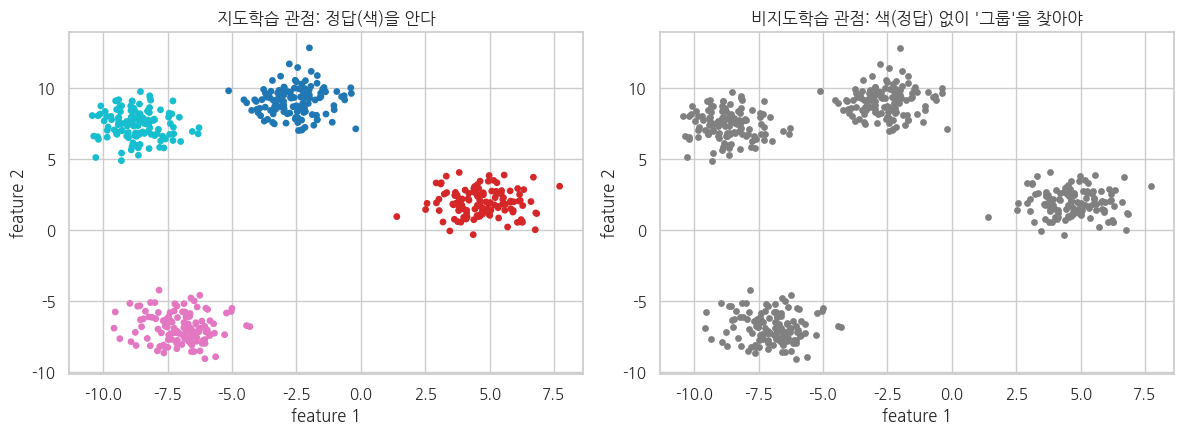

In [3]:
# ─────────────────────────────────────────────
# [C3] Part 1 · 📊 데이터로 확인해 봅시다 — 같은 데이터, 다른 시작점 [도식] 지도(정답 색칠) vs 비지도(색 없음) — 같은 데이터, 다른 시작점
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap="tab10", s=15)
axes[0].set_title("지도학습 관점: 정답(색)을 안다")
axes[1].scatter(X_blob[:, 0], X_blob[:, 1], c="gray", s=15)
axes[1].set_title("비지도학습 관점: 색(정답) 없이 '그룹'을 찾아야")
for ax in axes: ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
plt.tight_layout(); plt.show()
print("→ 오른쪽처럼 '정답 색이 없는' 회색 점들에서, 알고리즘이 스스로 그룹을 찾는 게 군집화입니다.")

> 🎯 **[C3] 확인하기**  
> 색이 없어도 알고리즘은 **거리**를 쓸 수 있습니다. 가까운 점끼리 묶는 것 — 거리 기반 군집화에서 사용하는 주요 단서입니다. 정답이 없다는 것은 '아무 정보도 없다'가 아니라 **'정답 대신 구조를 쓴다'** 는 뜻입니다.

> 👀 **[C3] 결과읽기**  
> 왼쪽은 정답(색)을 아는 지도학습 세계, 오른쪽은 정답 없는 비지도 세계입니다. 사람 눈엔 오른쪽에서도 "네 덩어리"가 보이죠? **그 '보이는 그룹'을 알고리즘이 자동으로 찾게** 하는 것이 군집화입니다.

> 📌 **실무 연결하기**  
> 비지도 군집화는 **이커머스** 고객 세그먼트(RFM), **금융** 이상거래 탐지, **제조** 불량 패턴 그룹, **마케팅** 시장 세분화에 쓰입니다. "라벨은 없지만 그룹은 있을 것 같다" 싶을 때 꺼내는 도구입니다.

## 🚦 짚고 넘어가기

다음 질문으로 핵심 개념을 점검합니다.

1. 지도학습과 비지도학습의 가장 큰 차이는 무엇인가요?
2. 군집화의 목표를 한 문장으로 설명합니다.
3. 정답이 없는데 결과가 좋은지 어떻게 판단할까요?

> ⏭️ **다음 학습 예고**  
> 가장 널리 쓰는 군집 알고리즘 — **K-Means**부터 시작합니다. "중심을 잡고, 가까운 점을 모으고, 중심을 옮긴다"는 단순한 반복입니다.

# Part 2. K-Means — 중심으로 그룹을 나눈다

가장 기본이 되는 군집 알고리즘입니다. 이름 그대로 **K개의 평균(Means, 중심)** 을 찾아 데이터를 나눕니다.

> ❓ **질문하기**  
> 중심점 몇 개로 어떻게 데이터를 그룹 짓나?

## 💡 쉽게 말하면 — 모임 장소를 정하는 과정

동호회원들의 모임 장소 k곳을 정한다고 합시다.

1. 일단 **k곳을 아무 데나** 찍습니다(중심 초기화).
2. 각 회원을 **가장 가까운 장소**에 배정합니다.
3. 각 장소를 **배정된 회원들의 한가운데**로 옮깁니다(중심 갱신).
4. 더 이상 안 변할 때까지 2~3을 반복합니다.

이게 K-Means의 전부입니다 — **배정 → 중심 이동**의 반복. 거리는 보통 유클리드 거리를 씁니다(앞서 다룬 거리 개념).

- **하이퍼파라미터:** `n_clusters`(=k, 사람이 지정), `n_init`(초기화 여러 번 시도 후 best).
- **잘 맞는 구조:** 중심 주위로 등방성에 가깝게 모이고 분산이 비슷한 군집. `inertia`는 같은 데이터·전처리에서 작을수록 더 조밀합니다.
- **약점:** k를 미리 정해야 함, 비구형 군집·이상치에 약함, 초기값에 따라 결과 변동(`k-means++`·`n_init`로 완화).

## 🔍 자세히 알아보기 — K-Means가 거리에 의존한다는 것

K-Means는 "가장 가까운 중심에 배정"합니다 — 즉 **거리**가 전부입니다(유클리드 거리). 그래서 두 가지가 따라옵니다.

1. **스케일링이 필수:** 연봉(만 단위)과 나이(수십 단위)를 그냥 두면 연봉이 거리를 독식합니다. 표준화로 공정하게.
2. **구형 군집 가정:** "중심에서 가까운 = 한 군집"이라 *둥근 덩어리*를 전제합니다. 길쭉하거나 휜 군집에는 약합니다(그래서 Part 4의 DBSCAN).

또 하나, K-Means는 **초기 중심 위치에 따라 결과가 달라질 수 있어** `n_init`(여러 번 초기화 후 best)과 `k-means++`(똑똑한 초기화)를 기본으로 씁니다. sklearn은 이미 `k-means++`가 기본입니다.

## 📊 데이터로 확인해 봅시다 — K-Means를 돌려 보기

> 🤔 **예상하기**  
> 정답(`y_blob`)을 주지 않고 X만 줍니다. K-Means가 찾아낸 군집이 실제 정답과 **얼마나 일치**할 것 같습니까?

▶️ **코드 실행하기 · 코드 셀 4 [C4]**

→ 빨간 X가 각 군집의 '중심'입니다. 정답 색 없이도 네 덩어리를 잘 찾아냈습니다.


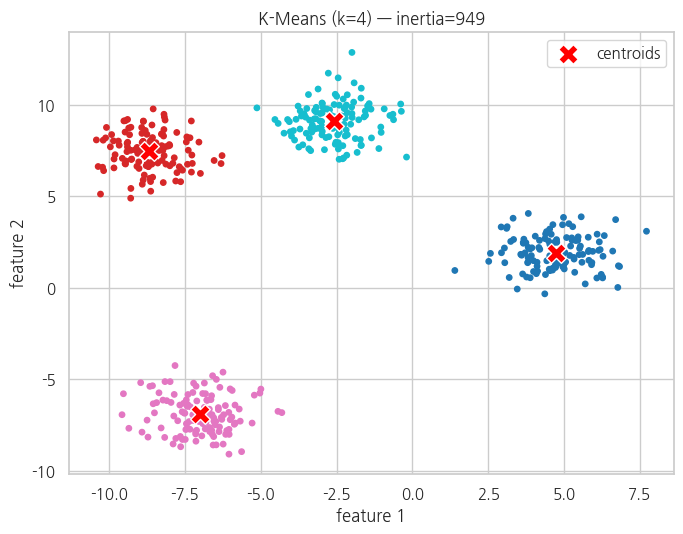

In [4]:
# ─────────────────────────────────────────────
# [C4] Part 2 · 📊 데이터로 확인해 봅시다 — K-Means를 돌려 보기 K-Means로 make_blobs를 군집화 (정답 없이 X만 준다)
# ─────────────────────────────────────────────
km = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)
labels = km.fit_predict(X_blob)        # 각 점의 군집 번호(0~3)

plt.figure(figsize=(7, 5.5))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=labels, cmap="tab10", s=15)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c="red", marker="X", s=200, edgecolor="white", label="centroids")
plt.title(f"K-Means (k=4) — inertia={km.inertia_:.0f}")
plt.xlabel("feature 1"); plt.ylabel("feature 2"); plt.legend()
plt.tight_layout(); plt.show()
print("→ 빨간 X가 각 군집의 '중심'입니다. 정답 색 없이도 네 덩어리를 잘 찾아냈습니다.")

> 🎯 **[C4] 확인하기**  
> 정답을 주지 않았는데도 K-Means가 찾아낸 군집이 실제 정답과 거의 일치합니다. 심어둔 구조가 또렷했기 때문입니다. **현실 데이터에서는 이렇게 깔끔하게 갈리는 일이 드물다**는 점을 기억해 둡니다.

> 👀 **[C4] 결과읽기**  
> 색이 K-Means가 _스스로 부여한_ 군집 번호이고, 빨간 X가 각 군집의 중심입니다. 정답(`y_blob`)을 주지 않았는데도 사람이 보는 네 덩어리를 잘 찾았습니다. 단, **군집 번호(0,1,2,3)에는 순서·의미가 없습니다** — 그냥 라벨일 뿐입니다(Part 6에서 의미를 부여).

> ⚠️ **K-Means는 스케일링에 민감:**  
> 거리 기반이라 단위가 다른 피처가 있으면 **반드시 `StandardScaler`로 표준화 먼저**. 위 합성 데이터는 이미 비슷한 스케일이라 생략했지만, 실데이터(Part 5~6)에선 필수입니다.

K-Means가 거리에 의존한다는 말의 결과를 눈으로 확인해 봅니다.

▶️ **코드 실행하기 · 코드 셀 5 [C5]**

→ K-Means는 '평균'으로 중심을 잡아 이상치에 민감합니다. DBSCAN은 설정한 밀도 기준에 따라 이런 점을 잡음 후보로 분리할 수 있습니다.


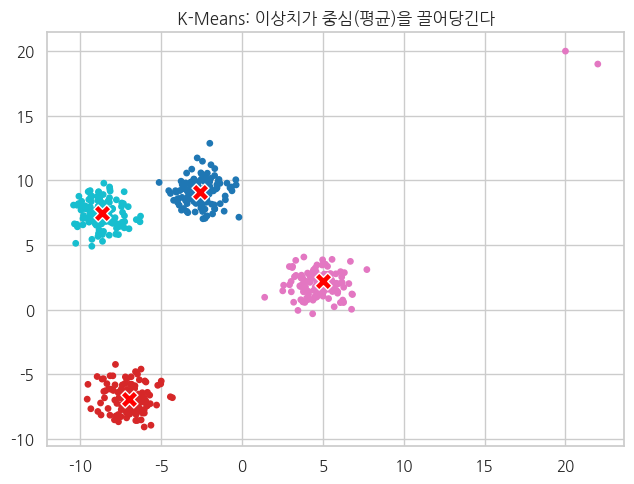

In [5]:
# [C5] Part 2 · 📊 데이터로 확인해 봅시다 — K-Means를 돌려 보기 K-Means의 약점 — 이상치에 끌려가는 중심
import numpy as np
X_out = np.vstack([X_blob, [[20, 20], [22, 19]]])    # 멀리 떨어진 이상치 2개 추가
lb_out = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_out)
plt.figure(figsize=(6.5, 5))
plt.scatter(X_out[:, 0], X_out[:, 1], c=lb_out.labels_, cmap="tab10", s=15)
plt.scatter(lb_out.cluster_centers_[:, 0], lb_out.cluster_centers_[:, 1], c="red", marker="X", s=150, edgecolor="white")
plt.title("K-Means: 이상치가 중심(평균)을 끌어당긴다")
plt.tight_layout(); plt.show()
print("→ K-Means는 '평균'으로 중심을 잡아 이상치에 민감합니다. DBSCAN은 설정한 밀도 기준에 따라 이런 점을 잡음 후보로 분리할 수 있습니다.")

> 👀 **[C5] 결과읽기**  
> 두 극단값이 평균인 중심을 끌어당깁니다. 이 그림은 K-Means가 이상값에 민감할 수 있음을 보여 주지만, DBSCAN의 잡음 판정이 곧 업무상 이상 거래 판정이라는 뜻은 아닙니다.

### K-Means가 "수렴"한다는 것

K-Means는 *배정 → 중심 이동*을 반복하다 **더 이상 배정이 바뀌지 않으면 멈춥니다**(수렴). 매 반복마다 inertia(군집 내 거리 제곱합)가 줄어들도록 보장돼 있어, 언젠가는 멈춥니다. 다만 *전역 최적*이 아니라 *지역 최적*에 멈출 수 있어(초기값 의존), `n_init`로 여러 번 시도해 가장 좋은 결과를 택합니다. [C6]에서 반복 횟수에 따라 중심이 이동하는 모습을 확인합니다.

▶️ **코드 실행하기 · 코드 셀 6 [C6]**

→ 반복할수록 중심이 자리를 잡습니다. 어느 순간부터 거의 안 움직이면 '수렴'한 것.


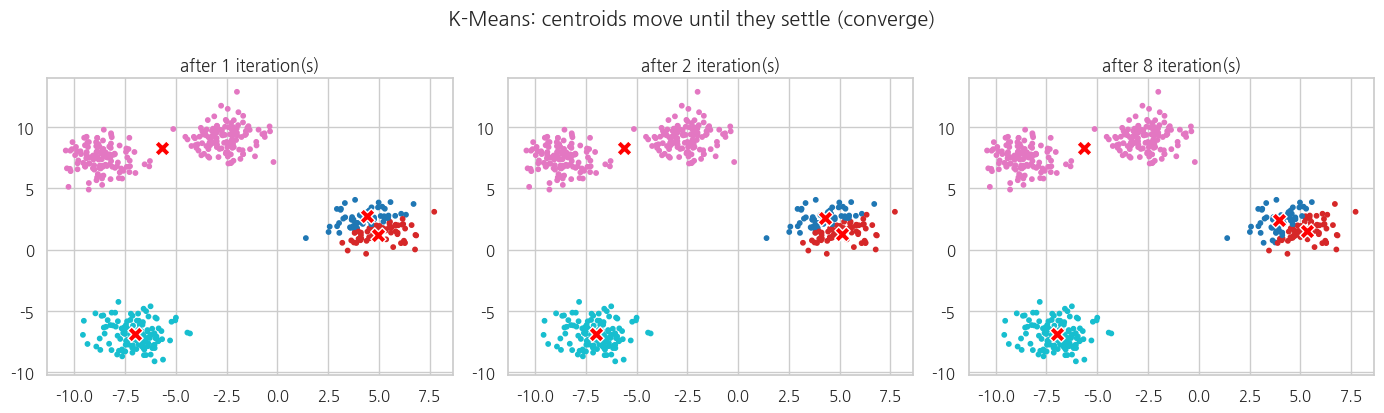

In [6]:
# [C6] Part 2 · 📊 데이터로 확인해 봅시다 — K-Means를 돌려 보기 K-Means 중심이 반복마다 이동하는 과정 (max_iter를 1,2,5로)
import numpy as np
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, it in zip(axes, [1, 2, 8]):
    m = KMeans(n_clusters=4, init="random", n_init=1, max_iter=it, random_state=1).fit(X_blob)
    ax.scatter(X_blob[:, 0], X_blob[:, 1], c=m.labels_, cmap="tab10", s=10)
    ax.scatter(m.cluster_centers_[:, 0], m.cluster_centers_[:, 1], c="red", marker="X", s=120, edgecolor="white")
    ax.set_title(f"after {it} iteration(s)")
plt.suptitle("K-Means: centroids move until they settle (converge)")
plt.tight_layout(); plt.show()
print("→ 반복할수록 중심이 자리를 잡습니다. 어느 순간부터 거의 안 움직이면 '수렴'한 것.")

> 👀 **[C6] 결과읽기**  
> 반복 횟수가 늘면서 중심이 안정됩니다. 다만 한 초기값에서 수렴했다는 사실은 전역 최솟값을 찾았다는 뜻이 아니므로 여러 초기화를 비교합니다.

> 📌 **K-Means의 사촌들:**  
> 데이터가 매우 크면 **MiniBatchKMeans**(일부 샘플로 빠르게), 군집이 "확률적으로 겹칠" 수 있으면 **GMM(가우시안 혼합)**, 중심 대신 실제 데이터 점을 대표로 쓰려면 **K-Medoids**가 있습니다. 모두 "중심/대표를 잡아 거리로 묶는" K-Means 가족입니다. 입문은 K-Means로 충분하고, 데이터 규모·모양에 따라 사촌들을 꺼냅니다.

## ⌨️ 백문이 불여일타! (1)

```
[문제]
1) `KMeans`의 `n_clusters`를 3과 6으로 바꿔 `X_blob`(정답은 4군집)을 각각 군집화해확인합니다.
2) 두 결과를 산점도로 나란히 그려, 잘못된 k가 군집을 어떻게 왜곡하는지 관찰해확인합니다.
```

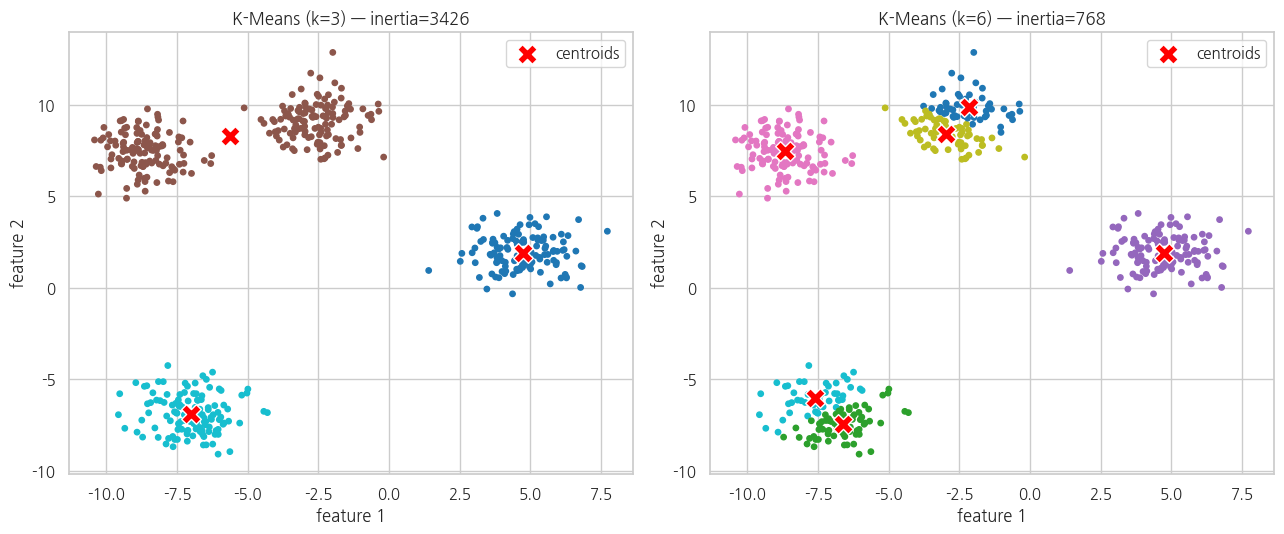

In [7]:
# [C7] Part 2 · ⌨️ 백문이 불여일타! (1) ⌨️ 백문이 불여일타! (1) — 잘못된 k(3, 6)로 군집화해 결과 비교

# 여기에 코드를 작성하세요
# ─────────────────────────────────────────────
# [C4-실습] Part 2 · k=3, k=6으로 X_blob 군집화 후 나란히 비교
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, k in zip(axes, [3, 6]):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_blob)
    ax.scatter(X_blob[:, 0], X_blob[:, 1], c=labels, cmap="tab10", s=15)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c="red", marker="X", s=200, edgecolor="white", label="centroids")
    ax.set_title(f"K-Means (k={k}) — inertia={km.inertia_:.0f}")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2"); ax.legend()

plt.tight_layout()
plt.show()

<details>
<summary>(클릭) 💡 힌트</summary>

- 군집 라벨은 `KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_blob)`로 얻습니다 — [C4]에서 본 그 사용법입니다.
- `plt.subplots(1, 2)`로 축 두 개를 만들고 k=3, 6을 하나씩 그리면 나란히 비교할 수 있습니다.
- `scatter`의 `c=`에 군집 라벨을 넣으면 군집이 색으로 구분됩니다.

</details>

> 💡 **K-Means 한 줄 정리:**  
> "k개 중심을 잡고, 가까운 점을 모으고, 중심을 평균으로 옮기길 반복." 단순하지만 빠르고 강력해 _가장 먼저 시도하는_ 군집 알고리즘입니다. 단 ① k를 정해야 하고, ② 둥근 군집을 가정하고, ③ 스케일링이 필요하고, ④ 이상치에 민감하다는 네 가지를 기억합니다. 이 약점들이 다음 도구(DBSCAN·계층)를 부릅니다.

> 📌 **`inertia`를 단독 품질 점수로 쓰지 않는 이유**  
> `inertia`는 `k`가 커질수록 줄어듭니다. 따라서 절대값이 작다는 이유만으로 좋은 군집이라 판단할 수 없습니다. 같은 데이터·거리·전처리에서 `k` 후보의 감소 폭을 보는 Elbow 용도로 사용하고, Silhouette·군집 크기·안정성·업무 해석을 함께 확인합니다. Silhouette도 구형·거리 기반 구조를 선호하므로 보편적인 정답표는 아닙니다.

> 📖 **k-means++ 한 줄:**  
> 초기 중심을 무작위로 찍으면 운 나쁘게 한쪽에 몰려 나쁜 군집이 될 수 있습니다. **k-means++** 는 _서로 멀리 떨어지도록_ 초기 중심을 똑똑하게 고릅니다(sklearn 기본값). 그래서 보통 `init` 옵션은 건드릴 필요 없고, `n_init`(몇 번 시도할지)만 충분히 주면 됩니다.

## 🚦 짚고 넘어가기

1. K-Means의 두 단계(배정·중심 이동)를 설명합니다.
2. K-Means가 가정하는 군집의 모양은 무엇입니까?
3. 군집 번호 "2"는 군집 "0"보다 큰 값인가요?

> ⏭️ **다음 학습 예고**  
> K-Means는 _k를 미리 정해야_ 합니다. 그런데 고객 데이터를 몇 그룹으로 나눠야 적당한지 어떻게 알까요? **Elbow와 Silhouette**으로 정합니다.

# Part 3. 군집 수(k) 결정 — Elbow & Silhouette

"고객을 3그룹? 5그룹? 10그룹?" — K-Means는 _우리가 k를 정해줘야_ 합니다. 정답이 없으니 **두 가지 지표**로 적정 k를 추정합니다.

> ❓ **질문하기**  
> 정답이 없는데 "몇 개 그룹이 적당한지" 어떻게 정할까?

## 💡 쉽게 말하면 — 두 가지 잣대(응집도와 분리도)

- **Elbow(엘보) 방법:** `k`를 늘리며 **inertia**의 감소 폭을 봅니다. 급격히 줄다가 완만해지는 지점은 복잡도를 더 늘려 얻는 이득이 작아지는 후보입니다.
- **Silhouette(실루엣) 점수:** 각 점이 자기 군집에는 가깝고 이웃 군집에는 먼 정도를 −1~1로 요약합니다. 1에 가까울수록 해당 거리 기준에서 응집·분리가 뚜렷합니다.

두 지표는 질문과 약점이 다릅니다. Elbow는 꺾임 판독이 주관적이고, Silhouette은 비볼록 군집·밀도 차이·고차원 거리에서 오해를 줄 수 있습니다. **둘 중 하나를 보편적으로 우선하지 않고**, 후보를 좁힌 뒤 안정성·군집 크기·업무 목적을 함께 확인합니다.

## 🔍 자세히 알아보기 — 두 잣대의 성격과 한계

| | **Elbow** | **Silhouette** |
| --- | --- | --- |
| 재는 것 | 군집 내 거리 제곱합 | 응집도와 가장 가까운 다른 군집의 분리도 |
| 읽는 법 | 감소 폭이 완만해지는 후보 | 후보 가운데 상대적으로 높은 값과 점별 분포 |
| 범위 | 0 이상, `k` 증가에 따라 감소 | −1 ~ 1 |
| 주요 한계 | 꺾임이 없거나 여러 개일 수 있음 | 거리·군집 모양에 민감하고 계산 비용이 큼 |

두 지표가 같은 후보를 지지하면 근거가 하나 더 생기지만 정답이 확정되는 것은 아닙니다. 서로 다르면 전처리·거리·군집 크기·안정성을 먼저 점검하고, 운영상 필요한 군집 수가 데이터 구조로도 뒷받침되는지 확인합니다.

> ⚠️ **Elbow의 한계:**  
> "꺾임(Elbow)"이 _항상 뚜렷하진 않습니다_. 완만하게 줄기만 해 꺾임이 애매한 경우가 많습니다. 그래서 Elbow만 믿지 말고 **Silhouette을 함께** 보고, 그래도 애매하면 _비즈니스 제약_(운영 가능한 그룹 수)으로 정합니다. "정답이 없다"는 비지도의 본질상, k 결정엔 늘 *판단*이 들어갑니다.

> 📌 **Elbow vs Silhouette, 무엇을 더 믿나:**  
> 둘이 다른 k를 가리키면 — 어느 한쪽을 자동으로 우선하지 않습니다. 다만 Silhouette은 계산이 더 무겁고, 군집이 길쭉하면 과소평가하기도 합니다. 가장 좋은 건 *둘 + 시각화(PCA 2D) + 비즈니스 제약*을 함께 보는 것. 한 지표에만 의존하지 않습니다.

## 📊 데이터로 확인해 봅시다 — Elbow와 실루엣을 직접 그려 보기

> 🤔 **예상하기**  
> `make_blobs`로 만든 데이터는 정답이 **4개 군집**입니다. Elbow 그래프의 꺾이는 지점과 실루엣의 최댓값이 **둘 다 4를 가리킬까요?** 하나만 맞힐 수도 있을까요?

▶️ **코드 실행하기 · 코드 셀 8 [C8]**

→ k=4 부근에서 '꺾임'이 보입니다. 그 뒤로는 k를 늘려도 inertia가 완만히 줄 뿐입니다.


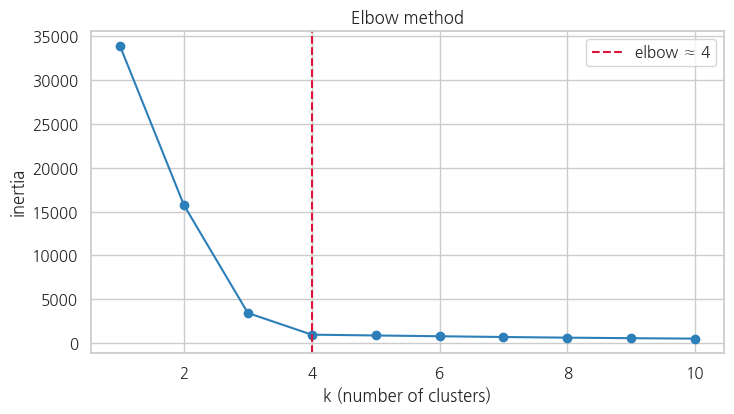

In [8]:
# ─────────────────────────────────────────────
# [C8] Part 3 · 📊 데이터로 확인해 봅시다 — Elbow와 실루엣을 직접 그려 보기 Elbow — k에 따른 inertia
# ─────────────────────────────────────────────
ks = range(1, 11)
inertias = [KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_blob).inertia_ for k in ks]
plt.figure(figsize=(7.5, 4.3))
plt.plot(list(ks), inertias, "o-", color="#2c7fb8")
plt.axvline(4, ls="--", color="crimson", label="elbow ≈ 4")
plt.xlabel("k (number of clusters)"); plt.ylabel("inertia")
plt.title("Elbow method"); plt.legend(); plt.tight_layout(); plt.show()
print("→ k=4 부근에서 '꺾임'이 보입니다. 그 뒤로는 k를 늘려도 inertia가 완만히 줄 뿐입니다.")

> 🎯 **[C8] 확인하기**  
> Elbow의 꺾임은 눈으로 판독하므로 후보 범위로 읽습니다. [C9]의 Silhouette과 같은 `k`를 지지하는지 확인하되, 일치만으로 정답이 확정되는 것은 아닙니다.

이어서 같은 후보를 Silhouette으로 확인합니다.

▶️ **코드 실행하기 · 코드 셀 9 [C9]**

→ 실루엣 점수가 가장 높은 k=4. Elbow와 같은 k를 지지하지만 정답이 확정되는 것은 아닙니다.


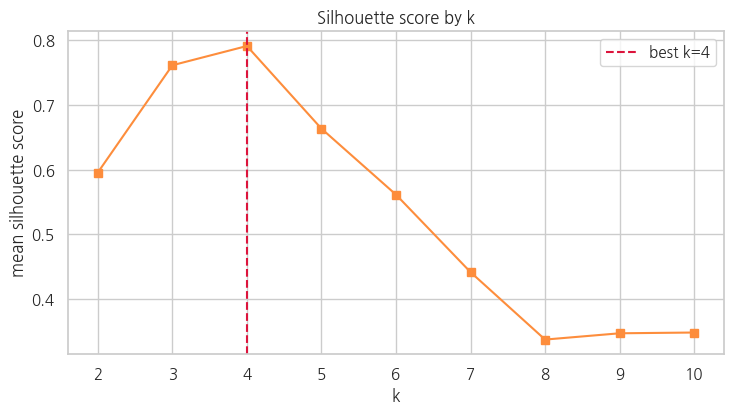

In [9]:
# ─────────────────────────────────────────────
# [C9] Part 3 · 📊 데이터로 확인해 봅시다 — Elbow와 실루엣을 직접 그려 보기 Silhouette — k에 따른 평균 실루엣 점수
# ─────────────────────────────────────────────
sil = []
for k in range(2, 11):     # 실루엣은 k>=2
    lb = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_blob)
    sil.append(silhouette_score(X_blob, lb))
plt.figure(figsize=(7.5, 4.3))
plt.plot(range(2, 11), sil, "s-", color="#fd8d3c")
best_k = list(range(2, 11))[int(np.argmax(sil))]
plt.axvline(best_k, ls="--", color="crimson", label=f"best k={best_k}")
plt.xlabel("k"); plt.ylabel("mean silhouette score")
plt.title("Silhouette score by k"); plt.legend(); plt.tight_layout(); plt.show()
print(f"→ 실루엣 점수가 가장 높은 k={best_k}. Elbow와 같은 k를 지지하지만 정답이 확정되는 것은 아닙니다.")

> 👀 **[C9] 결과읽기**  
> Elbow는 _꺾이는 지점_, Silhouette은 *가장 높은 지점*이 적정 k 후보입니다. 두 방법이 같은 `k`(여기서는 4)를 지지하면 후보 근거가 늘어납니다. 가리키는 값이 다르면 전처리·거리·안정성을 점검한 뒤 비즈니스 맥락(예: "마케팅팀이 다룰 수 있는 그룹 수")까지 고려해 결정합니다.

> 📌 **실무 팁:**  
> k는 _순수히 통계로만_ 정하지 않습니다. "통계가 4~5를 추천 + 마케팅팀이 4그룹을 원함 → k=4"처럼 **데이터와 비즈니스 제약을 함께** 봅니다. 정답이 없는 비지도학습에선 *맥락*이 더 중요합니다.

### 실루엣을 점별로 — 군집 품질을 더 자세히

평균 실루엣 점수 하나도 좋지만, **점마다의 실루엣**을 그리면 *어느 군집이 부실한지*까지 보입니다. 음수 실루엣을 가진 점은 "잘못된 군집에 배정됐을 가능성"이 있습니다.

▶️ **코드 실행하기 · 코드 셀 10 [C10]**

→ 각 군집의 실루엣 분포. 세로 길이는 군집 크기, 가로 길이는 점별 Silhouette입니다. 음수 값은 경계가 모호한 점을 뜻합니다.


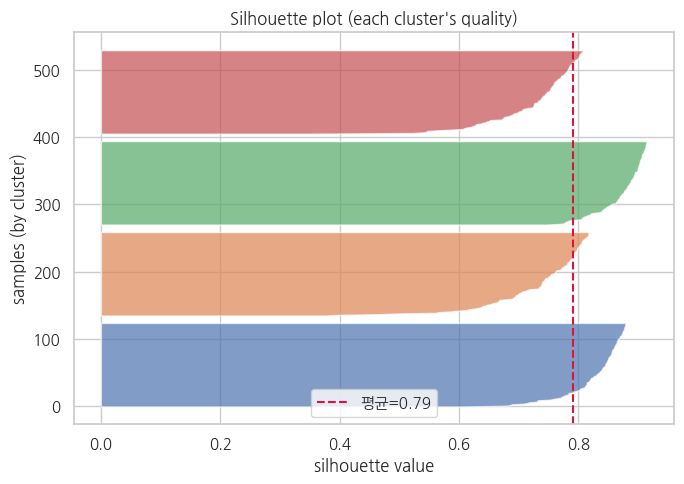

In [10]:
# [C10] Part 3 · 📊 데이터로 확인해 봅시다 — Elbow와 실루엣을 직접 그려 보기 실루엣 플롯 — 군집별 품질 분포
labels4 = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(X_blob)
sv = silhouette_samples(X_blob, labels4)
fig, ax = plt.subplots(figsize=(7, 5)); y_low = 0
for i in range(4):
    vals = np.sort(sv[labels4 == i])
    ax.fill_betweenx(np.arange(y_low, y_low + len(vals)), 0, vals, alpha=0.7)
    y_low += len(vals) + 10
ax.axvline(sv.mean(), color="crimson", ls="--", label=f"평균={sv.mean():.2f}")
ax.set_xlabel("silhouette value"); ax.set_ylabel("samples (by cluster)")
ax.set_title("Silhouette plot (each cluster's quality)"); ax.legend()
plt.tight_layout(); plt.show()
print("→ 각 군집의 실루엣 분포. 세로 길이는 군집 크기, 가로 길이는 점별 Silhouette입니다. 음수 값은 경계가 모호한 점을 뜻합니다.")

> 💡 **k 결정, 실무에서는:**  
> Elbow·Silhouette이 항상 *명확한 답*을 주진 않습니다(꺾임이 애매하거나 점수가 비슷할 때 많음). 그래서 실무에선 ① 두 지표를 함께 보고 _후보 범위_(예: 3~5)를 좁힌 뒤, ② **각 후보의 세그먼트가 비즈니스적으로 말이 되는지** 프로파일을 직접 보고, ③ _운영 가능한 그룹 수_(마케팅팀이 4개까지 다룰 수 있다면 4)를 함께 고려해 정합니다. 운영상 원하는 군집 수가 데이터 구조로 지지되지 않으면 억지로 분할하지 않고 피처·거리·알고리즘을 다시 검토합니다.

> 📖 **실루엣 점수 읽기 원칙**  
> 실루엣에는 산업과 데이터셋을 가로지르는 보편적 합격선이 없습니다. 같은 데이터·전처리·거리에서 `k` 후보를 상대 비교하고, 평균만 아니라 점별 분포·음수 비율·군집 크기를 함께 봅니다. 점수가 높아도 하나의 큰 군집과 작은 군집으로 갈린 결과가 업무 목적에 맞는지는 별도 판단입니다.

## ⌨️ 백문이 불여일타! (2)

```
[문제]
1) `make_blobs`의 `centers`를 5로 바꿔 새 데이터를 만듭니다.
2) 새 데이터로 k별 inertia(Elbow)와 Silhouette 점수를 다시 계산해, 두 지표가 k=5를 가리키는지 확인합니다.
```

In [11]:
# [C11] Part 3 · ⌨️ 백문이 불여일타! (2) ⌨️ 백문이 불여일타! (2) — centers=5 데이터에서 Elbow·Silhouette 확인

# 여기에 코드를 작성하세요

# ─────────────────────────────────────────────
# [C8-실습] Part 3 · centers=5로 새 데이터 생성 후 k별 inertia·silhouette 비교
# ─────────────────────────────────────────────
X_blob5, y_blob5 = make_blobs(n_samples=500, centers=5, cluster_std=1.0, random_state=42)

ks = range(1, 11)
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_blob5)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_blob5, labels) if k >= 2 else None)

for k, inr, sil in zip(ks, inertias, sil_scores):
    sil_str = f"{sil:.4f}" if sil is not None else "N/A"
    print(f"k={k:>2} | inertia={inr:>9.1f} | silhouette={sil_str}")

#     ① 왜 이렇게 짰나

# [C8] 구조를 그대로 따라, 반복문 안에서 inertia_와 silhouette_score를 같이 모았어요. k=1일 때는 군집이 하나뿐이라 실루엣이 정의 자체가 안 되니(N/A) 조건문으로 걸러줬어요.

# ② 어디서 틀릴 수 있나 — 그리고 실제로 여기서 틀렸어요

# 데이터는 진짜 5개 군집으로 만들었는데, 실루엣 점수는 k=4를 최고점(0.7328)으로 가리켜요. k=5는 0.6786으로 오히려 낮아요.
# 왜 이런 일이 생기냐면: cluster_std=1.0으로 다섯 덩어리를 500개 점에 흩뿌리다 보니, 5개 중 두 개가 우연히 서로 가깝게 배치돼서 "붙어있는 것처럼" 보이는 영역이 생겼을 가능성이 커요. 그 경우 k=4로 그 둘을 하나로 합쳐버리는 게 실루엣 관점에선 "더 깔끔하게 갈라진다"고 나올 수 있어요. 실루엣은 "각 점이 자기 군집과 가깝고 남의 군집과 먼가"만 보는 거라, 진짜 생성 구조(5개)와 통계적으로 가장 잘 갈라지는 구조(4개)가 다를 수 있다는 걸 숫자로 직접 확인한 거예요.

# ③ 결과를 왜 믿나 (그리고 왜 여기서는 안 믿어야 하나)

# 이게 바로 오늘 규칙에서 경고한 함정 ②의 실사판이에요: "실루엣이 가리키는 k를 무조건 정답으로 쓴다"가 위험한 이유를 실제 숫자로 봤어요. y_blob5(진짜 라벨)를 알고 만든 합성 데이터라서 우리는 "정답은 5"라는 걸 알지만, 실루엣만 봤으면 4를 골랐을 거예요.
# 실무 데이터엔 이런 정답 라벨이 없으니, 실루엣 최고점(k=4)을 무조건 믿는 대신 Elbow(꺾이는 지점), 도메인 지식, PCA 시각화를 같이 보고 최종 k를 정해야 해요 — 지표 하나에 의존하지 않는 게 핵심이에요.

k= 1 | inertia=  30210.8 | silhouette=N/A
k= 2 | inertia=  14726.1 | silhouette=0.5936
k= 3 | inertia=   3648.8 | silhouette=0.7084
k= 4 | inertia=   1543.4 | silhouette=0.7328
k= 5 | inertia=    924.0 | silhouette=0.6786
k= 6 | inertia=    836.1 | silhouette=0.6206
k= 7 | inertia=    762.0 | silhouette=0.5415
k= 8 | inertia=    693.1 | silhouette=0.4312
k= 9 | inertia=    628.4 | silhouette=0.3633
k=10 | inertia=    578.1 | silhouette=0.3424


<details>
<summary>(클릭) 💡 힌트</summary>

- 새 데이터는 `make_blobs(n_samples=500, centers=5, cluster_std=1.0, random_state=42)`처럼 만듭니다 — [C2]에서 본 그 함수입니다.
- k별 inertia는 `fit(...).inertia_`, Silhouette은 `silhouette_score(X, 라벨)`을 반복문으로 모으면 됩니다 — [C8]·[C9]의 흐름 그대로입니다.
- 그래프까지 그리지 않아도, `print`로 k별 수치를 나열해 비교하면 충분합니다.

</details>

## ⌨️ 백문이 불여일타! (3)

```
[문제]
1) 실데이터 `peng`(펭귄)의 수치 컬럼 4개를 `StandardScaler`로 표준화합니다.
2) k=2~6 각각 K-Means로 군집화해 실루엣 점수를 출력하고, 적정 k를 고릅니다.
```

In [12]:
# [C12] Part 3 · ⌨️ 백문이 불여일타! (3) ⌨️ 백문이 불여일타! (3) — penguins 실데이터에서 k별 실루엣 비교

# 여기에 코드를 작성하세요
# ─────────────────────────────────────────────
# [C9-실습] Part 3 · 펭귄 실데이터에 표준화 + k=2~6 실루엣
# ─────────────────────────────────────────────
X_peng = StandardScaler().fit_transform(peng[num_cols])

sil = []
for k in range(2, 7):
    lb = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_peng)
    sil.append(silhouette_score(X_peng, lb))

for k, s in zip(range(2, 7), sil):
    print(f"k={k} | silhouette={s:.4f}")

best_k = list(range(2, 7))[int(np.argmax(sil))]
print(f"\n→ 표준화 기준 최고 실루엣 k={best_k}")

k=2 | silhouette=0.5315
k=3 | silhouette=0.4472
k=4 | silhouette=0.3996
k=5 | silhouette=0.3789
k=6 | silhouette=0.3680

→ 표준화 기준 최고 실루엣 k=2


<details>
<summary>(클릭) 💡 힌트</summary>

- 수치 컬럼 4개의 이름은 준비 셀 [C2]의 `num_cols` 리스트에 이미 있습니다.
- 표준화는 `StandardScaler().fit_transform(...)`, 점수는 `silhouette_score(표준화한 X, 군집 라벨)`입니다 — [C9]에서 본 그 함수입니다.
- 실데이터 점수는 합성 데이터보다 낮게 나오는 게 보통입니다. 절대값보다 k끼리의 상대 비교로 고릅니다.

</details>

> 📌 **실무 연결하기**  
> 유통 매장·인재·학습자 그룹처럼 운영 가능한 군집 수에 제약이 있는 문제도 많습니다. 다만 운영팀이 세 그룹만 다룰 수 있다는 이유로 데이터가 지지하지 않는 `k=3`을 채택해서는 안 됩니다. 지표·안정성·최소 군집 크기로 가능한 후보를 먼저 정하고, 그 범위 안에서 운영 제약을 반영합니다.

## 🚦 짚고 넘어가기

1. Elbow 방법에서 "팔꿈치"는 무엇을 뜻하나요?
2. Silhouette 점수가 1에 가깝다는 것은?
3. k를 통계만으로 정해야 하나요?

> ⏭️ **다음 학습 예고**  
> K-Means는 *구형 군집*을 가정합니다. 그런데 군집이 초승달·고리 모양이거나 잡음이 많다면? **밀도 기반 DBSCAN**이 답입니다.

# Part 4. DBSCAN — 밀도로 그룹과 잡음을 가른다

K-Means는 둥근 군집엔 강하지만 *복잡한 모양*엔 약합니다. **DBSCAN**은 "**밀도가 높은 영역**"을 군집으로 보고, 어디에도 안 속한 점은 **잡음(Noise)** 으로 분리합니다.

> ❓ **질문하기**  
> 초승달 모양 군집, 그리고 이상치(잡음)는 어떻게 다룰까?

## 💡 쉽게 말하면 — 사람이 빽빽이 모인 곳이 "무리"

축제장을 위에서 본 장면을 떠올립니다. **사람이 빽빽한 곳**이 하나의 무리고, **드문드문 떨어진 사람**은 어느 무리도 아닌 _떠돌이(잡음)_ 입니다. DBSCAN이 정확히 이렇게 봅니다.

- **하이퍼파라미터:** `eps`(이웃으로 볼 반경), `min_samples`(무리가 되기 위한 최소 인원).
- **장점:** **k를 정할 필요 없음**(밀도가 군집 수를 결정), **임의 모양(비구형) 군집** 가능, 어느 밀집 영역에도 속하지 않는 **잡음 후보를 분리**(라벨 −1). 이 라벨만으로 업무상 이상 사례라고 단정하지 않습니다.
- **약점:** 밀도가 크게 다른 군집엔 약함, `eps`·`min_samples` 설정에 민감, 고차원에서 거리가 무뎌짐.

## 🔍 자세히 알아보기 — K-Means vs DBSCAN, 무엇을 언제?

| 질문                         |   K-Means   |      DBSCAN       |
| ---------------------------- | :---------: | :---------------: |
| 군집 수를 직접 지정하는가?     | ✅ `k` 지정 | ❌ 대신 `eps`·`min_samples` 조정 |
| 군집이 둥근가?               |     ✅      |     모양 무관     |
| 잡음/이상치가 많은가?        | ❌(다 배정) |     ✅(분리)      |
| 데이터가 매우 큰가?          |  ✅(빠름)   | △(느려질 수 있음) |
| 밀도가 군집마다 크게 다른가? |      △      |     ❌(약함)      |

> 💡 **실무 팁:**  
> 후보 알고리즘을 비교할 때는 내부 지표·시각화·안정성·업무 해석을 함께 확인합니다. "둥글고 군집 수 대략 알면 K-Means, 모양 불규칙·잡음 많고 k 모르면 DBSCAN"이 출발 기준입니다.

## 📊 데이터로 확인해 봅시다 — 초승달 데이터에서 두 알고리즘을 비교

K-Means와 DBSCAN을 같은 데이터에 돌려 봅니다. 둥근 덩어리가 아닌 **초승달 모양**에서 둘이 어떻게 갈리는지 확인합니다.

> 🤔 **예상하기**  
> 초승달 두 개가 나란히 있는 데이터에 K-Means(k=2)를 돌리면 어떻게 나눌까요? "가장 가까운 중심에 배정"이라는 규칙만으로 초승달을 따라갈 수 있을까요?

▶️ **코드 실행하기 · 코드 셀 13 [C13]**

→ K-Means는 '둥근 군집' 가정 때문에 초승달을 가로질러 자릅니다. DBSCAN은 밀도로 따라가 성공.


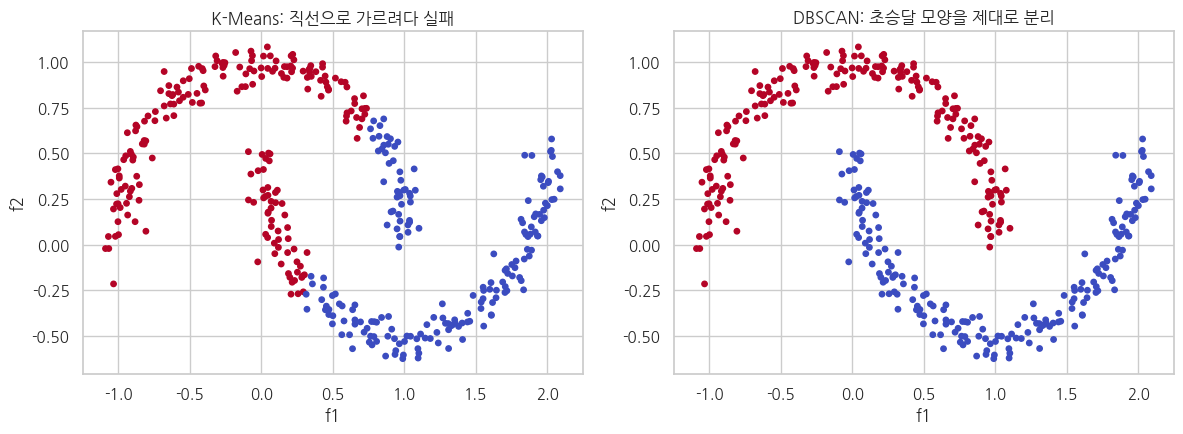

In [13]:
# ─────────────────────────────────────────────
# [C13] Part 4 · 📊 데이터로 확인해 봅시다 — 초승달 데이터에서 두 알고리즘을 비교 K-Means vs DBSCAN — 초승달(make_moons)에서 누가 옳은가
# ─────────────────────────────────────────────
km_moon = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(X_moon)
db_moon = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_moon)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c=km_moon, cmap="coolwarm", s=15)
axes[0].set_title("K-Means: 직선으로 가르려다 실패")
axes[1].scatter(X_moon[:, 0], X_moon[:, 1], c=db_moon, cmap="coolwarm", s=15)
axes[1].set_title("DBSCAN: 초승달 모양을 제대로 분리")
for ax in axes: ax.set_xlabel("f1"); ax.set_ylabel("f2")
plt.tight_layout(); plt.show()
print("→ K-Means는 '둥근 군집' 가정 때문에 초승달을 가로질러 자릅니다. DBSCAN은 밀도로 따라가 성공.")

## 🚦 짚고 넘어가기

1. DBSCAN이 K-Means와 달리 k를 안 받아도 되는 이유는 무엇입니까?
2. 라벨 −1은 무엇을 뜻합니까?
3. 초승달·고리 모양 군집엔 K-Means와 DBSCAN 중 무엇이 적합한가요?

> ⏭️ **다음 학습 예고**  
> 실무 데이터는 피처가 많아 산점도 한 장으로 군집을 보기 어렵습니다. 다음 Part에서는 PCA로 여러 피처를 2차원에 투영하고, 그림이 보존한 분산의 비율을 함께 확인합니다.

# Part 5. 차원축소 — 많은 피처를 눈으로 보기

지금까지 우리가 군집화한 데이터는 피처가 **두세 개**였습니다. 그래서 산점도 한 장으로 결과를 확인할 수 있었습니다. 그런데 실무 데이터는 열이 **수십 개**입니다. 13개짜리 데이터의 군집 결과를 어떻게 눈으로 확인할까요? 열 두 개를 골라 그리면 나머지 11개가 담긴 정보는 통째로 버려집니다.

여기서 비지도학습의 **두 번째 기둥**이 등장합니다. 군집화가 *행*을 묶는 일이라면, **차원축소(Dimensionality Reduction)** 는 *열*을 줄이는 일입니다.

> ❓ **질문하기**  
> 피처가 열세 개인 데이터를 어떻게 두 개의 축으로 눌러 담고, 그 과정에서 무엇을 잃는가?

## 💡 쉽게 말하면 — 그림자를 어느 방향에서 비출까

책상 위 물체에 손전등을 비추면 벽에 **그림자**가 생깁니다. 3차원 물체가 2차원 그림자로 눌린 것입니다.

여기서 중요한 건 **비추는 방향**입니다. 주전자를 옆에서 비추면 손잡이와 주둥이가 다 보이지만, 위에서 비추면 그냥 동그라미가 됩니다. **같은 물체인데 방향에 따라 남는 정보가 다릅니다.**

```text
    옆에서 비춤              위에서 비춤
      ▗▀▜▖                    ▗▄▖
     ▐  ▐▌  → 주전자!         ▐ ▌   → 그냥 원…
      ▝▄▟▘                    ▝▀▘
```

**PCA(Principal Component Analysis, 주성분 분석)** 가 하는 일이 정확히 이것입니다 — **가장 잘 보이는 방향을 데이터한테서 직접 찾아내** 그 방향으로 그림자를 만듭니다.

"가장 잘 보인다"의 기준은 **퍼짐(분산)** 입니다. 점들이 가장 넓게 흩어져 보이는 방향이 정보를 가장 많이 남기는 방향입니다. 한 점에 뭉쳐 보이는 방향으로 비추면 서로 다른 데이터가 구분되지 않으니까요.

## 🔍 자세히 알아보기 — 주성분과 설명 분산비

PCA는 중심화한 데이터에서 다음 축을 찾습니다.

1. **제1 주성분(PC1)** — 투영된 값의 분산이 가장 큰 방향
2. **제2 주성분(PC2)** — PC1과 직교하는 방향 가운데 분산이 가장 큰 방향
3. 필요한 수만큼 반복

새 축은 원래 피처들의 선형 결합입니다. 각 피처의 가중치인 적재량(Loading)을 보면 축의 구성을 해석할 수 있지만, 원래 피처 하나와 동일한 이름을 붙일 수는 없습니다.

### 얼마나 보존했는지 재는 자 — 설명 분산비

각 주성분이 전체 분산 가운데 차지하는 비율을 **설명 분산비(Explained Variance Ratio)** 라고 합니다.

$$	ext{설명 분산비}_k = rac{	ext{PC}_k 	ext{의 분산}}{	ext{전체 분산}}$$

- 앞에서부터 더한 값은 **누적 설명 분산비**입니다.
- 설명 분산비는 보존한 **분산의 비율**이지 의미·예측력·정보 가치의 보편적 비율이 아닙니다.
- 주성분 수는 시각화, 압축, 후속 모델 성능 등 목적에 따라 정합니다. `90%`는 가능한 기준 예시일 뿐 고정 규칙이 아닙니다.

> ⚠️ **주의하기 — 스케일 기준을 먼저 정합니다.**  
> scikit-learn의 `PCA`는 피처를 중심화하지만 자동으로 표준화하지 않습니다. 단위가 다르고 각 피처에 비슷한 가중치를 주려면 표준화를 먼저 적용합니다. 반대로 같은 단위이고 실제 분산 크기를 보존하는 것이 목적이라면 원 스케일을 유지할 수 있습니다. [C16]에서는 와인 피처에 같은 가중치를 주기 위해 표준화한 결과와 원 스케일 결과를 비교합니다.

> 🔗 **개념 연결하기**  
> `KMeans`와 PCA 모두 피처 스케일의 영향을 받지만 이유는 다릅니다. K-Means는 거리 계산이, PCA는 분산의 크기가 큰 단위에 좌우됩니다.

## 📊 데이터로 확인해 봅시다 — 13개 피처를 2차원에

와인 데이터(`load_wine`)를 씁니다. 이탈리아 같은 지역에서 재배된 **세 품종**의 와인 178병을 화학 성분 **13가지**로 측정한 자료입니다. 품종 정보(정답)가 있지만, 군집화 때와 마찬가지로 **모델에는 주지 않습니다** — 나중에 답을 맞춰 보는 용도로만 남겨 둡니다.

> 🤔 **예상하기**  
> 13개 피처를 2개로 누르면 전체 분산의 몇 %쯤 보존할 것 같습니까? 90% 이상일까요, 절반쯤일까요? 그리고 **누적 90%를 채우려면 주성분이 몇 개** 필요할까요?

▶️ **코드 실행하기 · 코드 셀 14 [C14]**

In [19]:
# ─────────────────────────────────────────────
# [C14] Part 5 · 📊 데이터로 확인해 봅시다 — 13개 피처를 2차원에
# 와인 13피처 → PCA — 실행하면 주성분별·누적 설명 분산비가 출력됩니다
# ─────────────────────────────────────────────
wine = load_wine(as_frame=True)
X_wine, y_wine = wine.data, wine.target      # y는 채점용으로만 보관합니다

print(f"와인 데이터: {X_wine.shape[0]}병 × {X_wine.shape[1]}개 성분")
print(f"품종 분포: {y_wine.value_counts().sort_index().to_dict()}")

# ① 표준화 — PCA 앞에서는 거의 필수입니다
Xw = StandardScaler().fit_transform(X_wine)

# ② 주성분을 전부 뽑아 설명 분산비를 봅니다
pca_all = PCA(random_state=RANDOM_STATE).fit(Xw)
ratio = pca_all.explained_variance_ratio_
cum = np.cumsum(ratio)

print("\n주성분별 설명 분산비 (상위 5개)")
for i in range(5):
    print(f"  PC{i+1}: {ratio[i]:.3f}   누적 {cum[i]:.3f}")

n90 = int(np.argmax(cum >= 0.90)) + 1
print(f"\nPC1+PC2 = {cum[1]:.3f}  → 2차원 그림은 전체 분산의 약 {cum[1]*100:.0f}%를 보존합니다")
print(f"누적 90%를 채우려면 주성분 {n90}개가 필요합니다 (13개 중)")

와인 데이터: 178병 × 13개 성분
품종 분포: {0: 59, 1: 71, 2: 48}

주성분별 설명 분산비 (상위 5개)
  PC1: 0.362   누적 0.362
  PC2: 0.192   누적 0.554
  PC3: 0.111   누적 0.665
  PC4: 0.071   누적 0.736
  PC5: 0.066   누적 0.802

PC1+PC2 = 0.554  → 2차원 그림은 전체 분산의 약 55%를 보존합니다
누적 90%를 채우려면 주성분 8개가 필요합니다 (13개 중)


### 🎯 예상과 맞았나요? — [C14]

> 👀 **[C14] 결과읽기**  
> PC1은 **36.2%의 분산**, PC2는 **19.2%의 분산**을 설명하며 누적 설명 분산은 **55.4%입니다**. 2차원 그림이 전체 분산의 절반 남짓을 보존한다는 뜻입니다. 누적 90%라는 예시 기준에는 주성분 8개가 필요합니다.  
> 따라서 2차원에서 점이 겹친다는 사실만으로 원래 13차원에서도 가깝다고 단정할 수 없습니다. 남은 분산과 업무상 중요한 저분산 신호가 투영에서 약해질 수 있습니다.

이제 2차원 투영과 누적 설명 분산 곡선을 함께 확인합니다.

▶️ **코드 실행하기 · 코드 셀 15 [C15]**

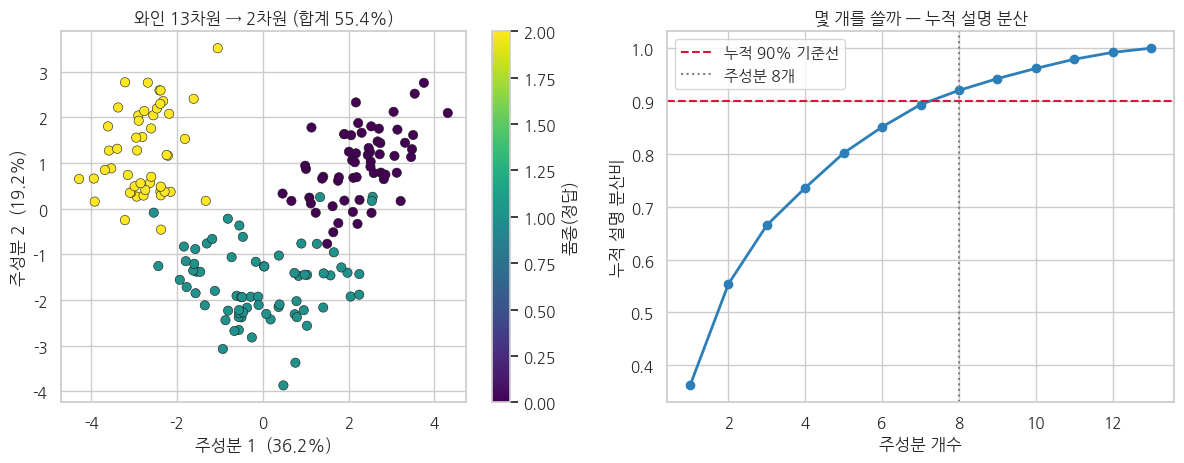

In [14]:
# ─────────────────────────────────────────────
# [C15] Part 5 · 📊 데이터로 확인해 봅시다 — 13개 피처를 2차원에
# 왼쪽: PCA 2D 산점도(품종 색) / 오른쪽: 누적 설명 분산 곡선
# ─────────────────────────────────────────────
X_pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sc = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_wine, cmap="viridis",
                     s=45, edgecolor="k", linewidth=0.4)
axes[0].set_xlabel(f"주성분 1  ({ratio[0]*100:.1f}%)")
axes[0].set_ylabel(f"주성분 2  ({ratio[1]*100:.1f}%)")
axes[0].set_title(f"와인 13차원 → 2차원 (합계 {cum[1]*100:.1f}%)")
plt.colorbar(sc, ax=axes[0], label="품종(정답)")

axes[1].plot(range(1, len(cum) + 1), cum, "o-", lw=2, color="#2c7fb8")
axes[1].axhline(0.90, color="crimson", ls="--", lw=1.5, label="누적 90% 기준선")
axes[1].axvline(n90, color="gray", ls=":", lw=1.5, label=f"주성분 {n90}개")
axes[1].set_xlabel("주성분 개수"); axes[1].set_ylabel("누적 설명 분산비")
axes[1].set_title("몇 개를 쓸까 — 누적 설명 분산")
axes[1].legend()

plt.tight_layout()
plt.show()

> 👀 **[C15] 결과읽기**  
> 왼쪽 그림의 색은 PCA가 만든 군집이 아니라, 투영을 마친 뒤 비교를 위해 입힌 **실제 품종 레이블**입니다. PCA 학습에는 `y_wine`을 사용하지 않았습니다. 세 품종이 2차원에서도 어느 정도 분리된다는 사실은 투영이 품종 차이와 관련된 분산을 보존했다는 사후 신호이며, 군집화 성공을 뜻하지는 않습니다.  
> 오른쪽 곡선은 주성분 수가 늘 때 보존되는 분산을 보여 줍니다. 시각화에는 2개를 쓰되 55.4%만 보존된 한계를 함께 적고, 모델 입력용 차원 수는 교차 검증 성능과 목적에 맞춰 정합니다.

> 📌 **실무 연결하기**  
> 차원축소는 제조 센서·금융 지표·설문 문항·임베딩처럼 피처가 많은 데이터의 탐색과 압축에 쓰입니다. 2차원 그림은 구조를 탐색하는 보조 수단이며, 원본 피처 프로파일과 정량 평가를 대체하지 않습니다.

## ⌨️ 백문이 불여일타! (4)

```
[문제]
1) PCA를 표준화 없이 원본 X_wine에 바로 적용해, PC1의 설명 분산비를 출력해확인합니다.
2) 그 값이 표준화했을 때(0.362)와 얼마나 다른가요? 왜 그렇게 됐을까요?
   힌트가 필요하면 X_wine의 열별 분산을 함께 출력해확인합니다.
3) 이 결과는 "PCA 앞에 표준화가 필요하다"를 어떻게 뒷받침합니까?
```

▶️ **코드 실행하기 · 코드 셀 16 [C16]**

In [20]:
# [C16] Part 5 · ⌨️ 백문이 불여일타! (4)
# ⌨️ 백문이 불여일타! (4) — 표준화를 빼면 PCA는 무엇을 찾는가

# 여기에 코드를 작성하세요

# ─────────────────────────────────────────────
# [실습] Part 5 · 표준화 없이 PCA → PC1 설명 분산비 비교
# ─────────────────────────────────────────────
pca_raw = PCA(random_state=42)
pca_raw.fit(X_wine)
print("표준화 없이 PC1:", round(pca_raw.explained_variance_ratio_[0], 4))

print()
print("열별 분산 (내림차순):")
print(X_wine.var().sort_values(ascending=False).round(2).to_string())

표준화 없이 PC1: 0.9981

열별 분산 (내림차순):
proline                         99166.72
magnesium                         203.99
alcalinity_of_ash                  11.15
color_intensity                     5.37
malic_acid                          1.25
flavanoids                          1.00
alcohol                             0.66
od280/od315_of_diluted_wines        0.50
total_phenols                       0.39
proanthocyanins                     0.33
ash                                 0.08
hue                                 0.05
nonflavanoid_phenols                0.02


<details>
<summary>(클릭) 💡 힌트</summary>

- 표준화 없이 적용하려면 `PCA(...).fit(X_wine)`처럼 **원본 데이터프레임을 그대로** 넣으면 됩니다.
- 설명 분산비는 `.explained_variance_ratio_`의 첫 번째 값을 봅니다.
- 열별 분산은 `X_wine.var().sort_values(ascending=False)`로 확인할 수 있습니다. 가장 큰 열과 가장 작은 열의 차이를 확인합니다.

</details>

## 🚦 짚고 넘어가기

1. PCA가 새 축을 고르는 기준은 무엇인가요? 그 축에 "알코올 축" 같은 이름을 붙일 수 없는 이유는요?
2. 누적 설명 분산비가 55%인 2차원 그림을 보고 "두 점이 겹치니 같은 무리다"라고 판단하면 왜 위험한가요?
3. PCA 앞에 표준화를 빼면 무슨 일이 벌어지나요?

> ⏭️ **다음 학습 예고**  
> 이제 도구가 갖춰졌습니다 — 군집으로 행을 묶고, PCA로 열을 줄여 눈으로 확인할 수 있습니다. 그런데 정작 어려운 일이 남았습니다. **군집 번호 0·1·2는 그 자체로 아무 의미가 없습니다.** 다음 Part에서 이 번호를 마케팅팀이 쓸 수 있는 말로 번역합니다.

# Part 6. 세그먼트 해석 — 군집을 비즈니스 의미로

군집화의 *진짜 어려움*은 알고리즘이 아니라 **그 다음**입니다. K-Means가 "군집 0,1,2"를 줬는데 — _그래서 뭐?_ 이 번호를 **행동 가능한 의미**로 바꿔야 가치가 생깁니다.

> ❓ **질문하기**  
> 의미 없는 군집 번호를 어떻게 "마케팅에 쓸 인사이트"로 바꾸나?

## 💡 군집 번호는 그 자체로 무의미하다

K-Means가 준 "군집 1"은 *그냥 라벨*입니다. 순서도 크기도 없습니다. 의미는 우리가 **각 군집의 특성을 분석해 부여**합니다.

방법: 각 군집의 **피처 평균(프로파일)** 을 비교 → "군집 0은 _몸집 크고 부리 긴_ 그룹" 같은 특징을 읽고 → **비즈니스 라벨**("대형 펭귄종", 고객이라면 "고가치 충성 고객")로 번역.

앞서 준비한 **고객 데이터**로 해봅시다.

## 🔍 자세히 알아보기 — 세그먼트를 '액션'으로 번역하기

세그먼트에 비즈니스 라벨을 붙인 뒤에는 _어떤 액션을 검증할지_ 가설을 정합니다.

| 세그먼트(예)          | 특성      | 액션                      |
| --------------------- | --------- | ------------------------- |
| VIP(고지출·잦은 방문) | 충성도↑   | 리텐션·VIP 혜택·추천 요청 |
| 이탈위험(오래 안 옴)  | 최근성↓   | 재유치 쿠폰·리마인드      |
| 신규·탐색             | 방문 적음 | 온보딩·첫 구매 유도       |

> 🎯 군집화의 끝은 _"군집을 찾았다"_ 가 아니라 _"각 군집에 무엇을 할지 정했다"_ 입니다. [A] 태도 — **정답 없는 결과를 비즈니스 행동으로 번역**하는 것 — 이 비지도학습의 본질입니다.

> 📌 **실무 연결하기**  
> 세그먼테이션은 이커머스·금융·통신·헬스케어에서 탐색과 가설 수립에 활용됩니다. "전체를 하나로 보지 말고, 비슷한 그룹별로 다르게 대응"하는 게 핵심.

### 세그먼트를 어떻게 "검증"하나 (정답이 없는데)

정답이 없으니 *간접 검증*을 씁니다.

- **안정성(Stability):** 데이터를 조금 바꾸거나(부트스트랩) 시드를 바꿔도 *비슷한 세그먼트*가 나오는가? 매번 크게 달라지면 신뢰↓.
- **해석 가능성:** 각 세그먼트가 _한 문장으로 설명되는가_("고지출·잦은 방문 VIP")? 설명이 안 되면 의미 없는 분할일 수 있음.
- **차별성:** 세그먼트끼리 _액션이 달라지는가_? 모두 같은 마케팅을 해야 한다면 나눈 의미가 없음.
- **외부 검증:** 군집화에 쓰지 않은 지표나 이후 기간의 결과가 세그먼트별로 다른가? 같은 데이터의 사후 차이는 연관성이지 액션 효과가 아닙니다.

> 🎯 "통계 점수가 높다"가 아니라 **나눈 결과가 반복해서 관찰되고 후속 실험의 의사결정을 개선하는가**를 확인해야 합니다.

## 📊 데이터로 확인해 봅시다 — 고객을 세 갈래로 나눠 보기

이제 마케팅팀의 요청에 답합니다. 고객 1,200명을 세 숫자만으로 나눠 보겠습니다.

> 🤔 **예상하기**  
> 실루엣이 가장 높은 k는 몇일까요? 그리고 **실루엣이 고른 k를 그대로 믿어도 될까요?** (힌트 — 마케팅팀이 관리할 수 있는 세그먼트 수도 제약입니다)

▶️ **코드 실행하기 · 코드 셀 17 [C17]**

k별 실루엣: {2: np.float64(0.64), 3: np.float64(0.72), 4: np.float64(0.513), 5: np.float64(0.407), 6: np.float64(0.402)}
→ 실루엣이 가장 높은 k = 3

세그먼트 크기: {0: 349, 1: 539, 2: 312}


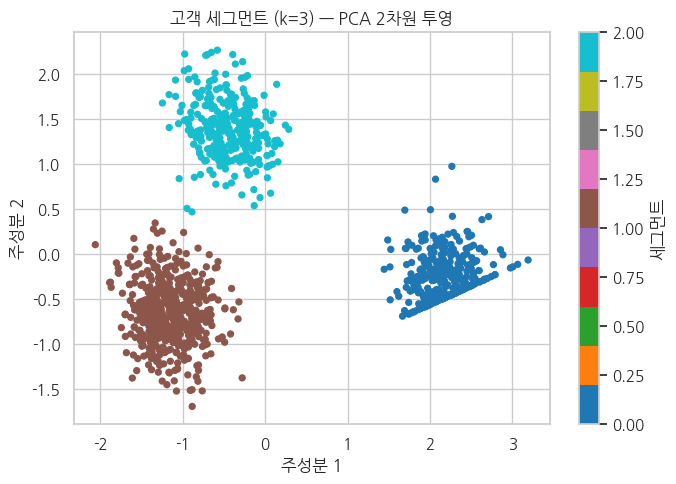

In [15]:
# ─────────────────────────────────────────────
# [C17] Part 6 · 📊 데이터로 확인해 봅시다 — 고객을 세 갈래로 나눠 보기 고객 세그먼트 찾기 — ① 스케일링 → ② k 결정 → ③ 군집화 → ④ PCA 2D
# (실행하면 k별 실루엣과 2D 산점도가 나옵니다)
# ─────────────────────────────────────────────
# ① 스케일링 — 단위가 다른 세 피처에 같은 가중치를 주기 위해 적용합니다 (시청은 시간, 세션은 회, 경과일은 일)
Xc = StandardScaler().fit_transform(cust[CUST_FEAT])

# ② k 결정 — 실루엣이 가장 높은 k
sil_k = {k: silhouette_score(Xc, KMeans(n_clusters=k, n_init=10,
                                        random_state=RANDOM_STATE).fit_predict(Xc))
         for k in range(2, 7)}
best_k = max(sil_k, key=sil_k.get)
print("k별 실루엣:", {k: round(v, 3) for k, v in sil_k.items()})
print(f"→ 실루엣이 가장 높은 k = {best_k}")

# ③ 군집화
cust["segment"] = KMeans(n_clusters=best_k, n_init=10,
                         random_state=RANDOM_STATE).fit_predict(Xc)

# ④ PCA 2D — 3차원을 2차원으로 눌러 눈으로 확인
Xc_2d = PCA(n_components=2).fit_transform(Xc)
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(Xc_2d[:, 0], Xc_2d[:, 1], c=cust["segment"], cmap="tab10", s=18)
ax.set_xlabel("주성분 1"); ax.set_ylabel("주성분 2")
ax.set_title(f"고객 세그먼트 (k={best_k}) — PCA 2차원 투영")
plt.colorbar(sc, ax=ax, label="세그먼트")
plt.tight_layout(); plt.show()

print(f"\n세그먼트 크기: {cust['segment'].value_counts().sort_index().to_dict()}")

> 🎯 **[C17] 확인하기**  
> 실루엣이 가리키는 k와 우리가 채택할 k가 반드시 같아야 하는 것은 아닙니다. 마케팅팀이 관리할 수 있는 세그먼트 수, 각 세그먼트의 최소 규모 같은 **운영 제약**이 함께 들어갑니다. 숫자는 후보를 좁혀줄 뿐, 최종 결정은 사람이 합니다.

이어서 확인해 봅니다.

▶️ **코드 실행하기 · 코드 셀 18 [C18]**

In [16]:
# ─────────────────────────────────────────────
# [C18] Part 6 · 📊 데이터로 확인해 봅시다 — 고객을 세 갈래로 나눠 보기 세그먼트 프로파일 → 페르소나 이름과 액션으로 번역
# (실행하면 프로파일 표와 세그먼트 카드가 나옵니다)
# ─────────────────────────────────────────────
profile = cust.groupby("segment")[CUST_FEAT].mean().round(1)
profile["이탈률"] = cust.groupby("segment")["churn"].mean().round(3)
profile["인원"] = cust["segment"].value_counts().sort_index()

print("=== 세그먼트 프로파일 ===")
print(profile.to_string())

# 프로파일을 읽어 페르소나와 액션을 붙입니다 (판단은 사람이 합니다)
print("\n=== 세그먼트 카드(액션은 검증할 가설) ===")
for s, row in profile.iterrows():
    if row["days_since_last_watch"] > 35:
        persona, action = "이탈 임박 휴면", "복귀 메시지 실험 후보 (효과는 별도 검증)"
    elif row["watch_hours_last_month"] > 30:
        persona, action = "충성 단골", "유지 전략 실험 후보 (효과는 별도 검증)"
    else:
        persona, action = "저관여 라이트", "취향 기반 추천 실험 후보"
    print(f"\n[세그먼트 {s}] {persona}  ({int(row['인원'])}명, 이탈률 {row['이탈률']:.1%})")
    print(f"  근거: 지난달 시청 {row['watch_hours_last_month']:.0f}시간 · "
          f"월 {row['sessions_per_month']:.1f}회 시청 · 마지막 시청 {row['days_since_last_watch']:.0f}일 전")
    print(f"  액션: {action}")

print("\n→ 번호가 아니라 '이 세그먼트는 누구인가'로 번역해야 마케팅팀이 쓸 수 있습니다.")

=== 세그먼트 프로파일 ===
         watch_hours_last_month  sessions_per_month  days_since_last_watch    이탈률   인원
segment                                                                               
0                          43.8                 9.5                    3.6  0.046  349
1                           8.8                 2.3                   19.8  0.173  539
2                          24.7                 5.4                   48.0  0.577  312

=== 세그먼트 카드(액션은 검증할 가설) ===

[세그먼트 0] 충성 단골  (349명, 이탈률 4.6%)
  근거: 지난달 시청 44시간 · 월 9.5회 시청 · 마지막 시청 4일 전
  액션: 유지 전략 실험 후보 (효과는 별도 검증)

[세그먼트 1] 저관여 라이트  (539명, 이탈률 17.3%)
  근거: 지난달 시청 9시간 · 월 2.3회 시청 · 마지막 시청 20일 전
  액션: 취향 기반 추천 실험 후보

[세그먼트 2] 이탈 임박 휴면  (312명, 이탈률 57.7%)
  근거: 지난달 시청 25시간 · 월 5.4회 시청 · 마지막 시청 48일 전
  액션: 복귀 메시지 실험 후보 (효과는 별도 검증)

→ 번호가 아니라 '이 세그먼트는 누구인가'로 번역해야 마케팅팀이 쓸 수 있습니다.


### 📇 세그먼트 카드 + 해설

> **워크플로:** 스케일링 → 실루엣으로 k 선택 → K-Means → PCA 2D는 시각화에만 사용 → 프로파일로 비즈니스 라벨.
> **결과:** 고객이 "VIP / 이탈위험 / 일반" 같은 *행동 가능한 그룹*으로 나뉨. 각 그룹에 대한 서로 다른 마케팅 가설(VIP 리텐션, 이탈위험 재유치)을 설계할 수 있음.
> **검증(정답 없음):** 실루엣 점수(통계) + _프로파일이 비즈니스적으로 말이 되는가_(해석)로 함께 판단. 마케팅팀과 라벨을 검토해 확정.

> 🚀 **더 나아가기**  
> `KMeans`를 `DBSCAN`으로 바꾸면 세그먼트가 어떻게 달라질까요? 또는 피처에 `watch_hours_last_month/sessions_per_month`(세션당 시청 시간) 같은 파생 피처를 더해 세그먼트가 더 선명해지는지 실험합니다.

> 💡 **세그먼트 카드 작성 팁:**  
> 비지도 결과는 *재현·설득 가능*해야 합니다. 카드에 **(1) 군집 전처리(스케일링)와 시각화(PCA 2D), (2) k 결정 근거(실루엣·비즈니스), (3) 세그먼트 수와 각 프로파일, (4) 비즈니스 라벨과 액션, (5) 한계(정답 없음을 어떻게 검증했나)** 를 기록합니다. 특히 *(4) 라벨·액션*과 *(5) 검증*이 핵심 — 숫자 군집을 *의사결정*으로 바꾼 기록이 진짜 산출물입니다.

### 세그먼트별 특성을 그림으로 — 박스플롯

표(프로파일)뿐 아니라 *분포*까지 보면 세그먼트 차이가 더 분명합니다. 군집별로 한 특성의 분포를 비교합니다.

▶️ **코드 실행하기 · 코드 셀 19 [C19]**

→ 평균만 보면 놓치는 것이 보입니다 — 각 세그먼트 안에서도 편차가 있습니다.


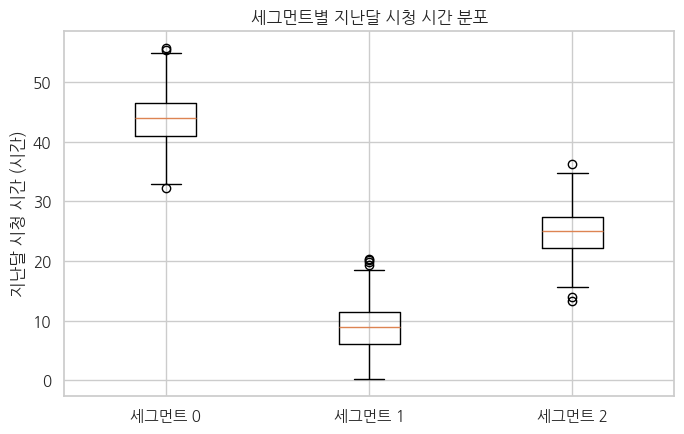

In [17]:
# ─────────────────────────────────────────────
# [C19] Part 5 · 📊 데이터로 확인해 봅시다 — 고객을 세 갈래로 나눠 보기
# 세그먼트별 지난달 시청 시간 분포 (실행하면 박스플롯이 그려집니다)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
data_by_seg = [cust.loc[cust["segment"] == s, "watch_hours_last_month"].values
               for s in sorted(cust["segment"].unique())]
ax.boxplot(data_by_seg, tick_labels=[f"세그먼트 {s}" for s in sorted(cust["segment"].unique())])
ax.set_ylabel("지난달 시청 시간 (시간)")
ax.set_title("세그먼트별 지난달 시청 시간 분포")
plt.tight_layout()
plt.show()

print("→ 평균만 보면 놓치는 것이 보입니다 — 각 세그먼트 안에서도 편차가 있습니다.")

## 🚦 짚고 넘어가기

1. 군집 번호 자체에 의미가 있나요? 의미는 어떻게 부여하나요?
2. 실데이터 군집화 전에 반드시 해야 할 전처리는?
3. 정답이 없는 군집 결과를 어떻게 "검증"하나요?

> ⏭️ **다음 학습 예고**  
> 배운 전 과정(스케일링 → 군집 → k 결정 → 해석)을 하나의 **고객 세그먼테이션 파이프라인**으로 묶어봅니다.

# Part 7. 군집을 피처로 — 비지도가 지도를 돕는다

지금까지 우리는 **정답 없이** 고객을 세 갈래로 나눴습니다. 그리고 각 세그먼트에 이름과 액션을 붙였습니다. 여기서 끝나도 충분히 값어치 있는 분석입니다.

그런데 한 가지가 더 가능합니다. 마케팅팀에는 **정답이 있는 질문**도 있습니다 — _"이 고객이 이탈할까?"_ 입니다. 지난 시간까지 배운 지도학습의 영역입니다.

그럼 이렇게 물을 수 있습니다. **오늘 찾아낸 세그먼트를, 그 이탈 예측에 피처로 넣으면 도움이 될까요?**

> ❓ **질문하기**  
> 정답 없이 발견한 그룹을 정답 있는 예측에 되먹일 수 있는가, 그리고 그때 무엇을 조심해야 하는가?

## 💡 쉽게 말하면 — 군집 중심까지의 거리를 새 좌표로 쓴다

세 숫자가 비슷해 보여도 어느 중심에 얼마나 가까운지를 계산하면 비선형 위치 관계가 드러날 수 있습니다. scikit-learn의 `KMeans.transform()`은 각 관측치에서 **모든 군집 중심까지의 거리**를 반환합니다. `k=3`이면 거리 피처 3개가 생깁니다.

군집 번호 0·1·2를 숫자 한 열로 그대로 넣으면 `2 > 1 > 0` 같은 순서가 있다는 잘못된 가정을 줄 수 있습니다. 이 노트북은 번호 대신 중심거리 피처를 사용합니다.

- **도움이 될 수 있는 경우:** 원본 피처와 타깃의 관계가 중심 주변의 영역처럼 비선형 구조를 가질 때
- **도움이 없을 수 있는 경우:** 기존 모델이 원본 피처에서 같은 구조를 이미 학습하거나, 군집이 타깃과 무관할 때

군집 파생 피처도 가설이므로 같은 검증 조건에서 추가 효과를 확인합니다.

## 🔍 자세히 알아보기 — 구현과 누수 함정

### 구현 — `KMeans`를 `Pipeline` 안에 둔다

`KMeans.transform()`은 각 점에서 군집 중심까지의 거리 `k`개를 만듭니다. `FeatureUnion`으로 표준화된 원본 피처와 중심거리 피처를 나란히 붙입니다.

```python
feat = FeatureUnion([
    ("original", "passthrough"),
    ("cluster_distance", KMeans(n_clusters=3)),
])
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("feat", feat),
    ("clf", LogisticRegression()),
])
```

### 함정 — `KMeans`도 `fit`을 한다

| 방식 | 중심을 학습하는 데이터 | 판정 |
| --- | --- | --- |
| 전체 데이터로 스케일러·KMeans `fit` 후 CV | 검증 조각 포함 | ❌ 절차상 누수 |
| `Pipeline` 전체를 CV에 전달 | 각 겹의 학습 조각만 | ✅ 정상 |

공정한 비교를 위해 두 방식 모두 **원본 표준화 피처 3개 + 중심거리 피처 3개**라는 같은 표현을 사용합니다. 표현이 다르면 점수 차이를 누수 효과로 해석할 수 없습니다.

> ⚠️ **주의하기**  
> 누수가 항상 점수를 크게 올리지는 않습니다. 점수 차이가 작거나 반대 방향이어도 전체 데이터에 `fit`했다면 절차는 잘못된 것입니다. 결과 숫자가 아니라 `fit` 범위로 판정합니다.

> 📌 **실무 연결하기**  
> 군집 파생 피처는 거래·구매·설비 상태의 중심거리나 세그먼트 소속을 요약할 때 사용할 수 있습니다. `StandardScaler`·`KMeans`·`PCA`처럼 데이터에서 기준을 배우는 변환기는 평가 파이프라인 안에 둡니다.

## 📊 데이터로 확인해 봅시다 — 같은 표현으로 세 방식을 비교

같은 이탈 예측 문제를 세 가지로 비교합니다.

1. **군집 파생 피처 없음** — 표준화한 원본 3개 피처
2. **`Pipeline` 안 KMeans** — 원본 3개 + 각 학습 조각에서 만든 중심거리 3개
3. **전체-fit KMeans** — 원본 3개 + 전체 데이터에서 미리 만든 중심거리 3개(누수)

> 🤔 **예상하기**  
> ②가 ①보다 나을지 예상합니다. ③은 절차상 누수이지만, 점수가 반드시 ②보다 높아야 할까요?

▶️ **코드 실행하기 · 코드 셀 20 [C20]**

In [18]:
# ─────────────────────────────────────────────
# [C20] Part 7 · 📊 데이터로 확인해 봅시다 — 같은 표현으로 세 방식을 비교
# 군집 중심거리 피처 3방 비교 (실행하면 F1 평균과 차이가 출력됩니다)
# ─────────────────────────────────────────────
X_cust = cust[CUST_FEAT]
y_cust = cust["churn"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def lr():
    return LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)

# ① 군집 파생 피처 없음
plain = Pipeline([("scale", StandardScaler()), ("clf", lr())])
s_plain = cross_val_score(plain, X_cust, y_cust, cv=cv, scoring="f1")

# ② Pipeline 안 KMeans — 각 겹의 학습 조각에서만 중심을 fit
feat = FeatureUnion([
    ("original", "passthrough"),
    ("cluster_distance", KMeans(n_clusters=3, n_init=10,
                                random_state=RANDOM_STATE)),
])
inside = Pipeline([("scale", StandardScaler()), ("feat", feat), ("clf", lr())])
s_inside = cross_val_score(inside, X_cust, y_cust, cv=cv, scoring="f1")

# ③ 전체 데이터로 스케일러·KMeans fit → 같은 중심거리 표현 생성 (누수)
scaler_all = StandardScaler().fit(X_cust)
X_scaled_all = scaler_all.transform(X_cust)
km_all = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_scaled_all)
X_leak = np.column_stack([X_scaled_all, km_all.transform(X_scaled_all)])
s_leak = cross_val_score(lr(), X_leak, y_cust, cv=cv, scoring="f1")

print("이탈 예측 F1 (층화 5겹 교차 검증)")
print(f"  ① 군집 파생 피처 없음         {s_plain.mean():.4f} ± {s_plain.std():.4f}")
print(f"  ② Pipeline 안 중심거리 (정상) {s_inside.mean():.4f} ± {s_inside.std():.4f}"
      f"   변화 {s_inside.mean() - s_plain.mean():+.4f}")
print(f"  ③ 전체-fit 중심거리 (누수)    {s_leak.mean():.4f} ± {s_leak.std():.4f}"
      f"   변화 {s_leak.mean() - s_plain.mean():+.4f}")
print()
print(f"→ 관측된 파생 피처 효과 (② − ①) {s_inside.mean() - s_plain.mean():+.4f}")
print(f"  전체-fit과 정상 절차 차이 (③ − ②) {s_leak.mean() - s_inside.mean():+.4f}")

이탈 예측 F1 (층화 5겹 교차 검증)
  ① 군집 파생 피처 없음         0.4751 ± 0.0302
  ② Pipeline 안 중심거리 (정상) 0.5125 ± 0.0513   변화 +0.0374
  ③ 전체-fit 중심거리 (누수)    0.5116 ± 0.0434   변화 +0.0365

→ 관측된 파생 피처 효과 (② − ①) +0.0374
  전체-fit과 정상 절차 차이 (③ − ②) -0.0009


> 🎯 **[C20] 확인하기**

| 방식 | F1 평균 | 기준 대비 |
| --- | ---: | ---: |
| ① 군집 파생 피처 없음 | 0.4751 | — |
| ② `Pipeline` 안 중심거리 | **0.5125** | **+0.0374** |
| ③ 전체-fit 중심거리(누수) | 0.5116 | +0.0365 |

두 가지를 구분합니다.

1. 이 합성 데이터에서는 정상 절차의 중심거리 피처가 F1 평균을 **+0.0374** 높였습니다. 이탈률을 숨은 세그먼트별로 다르게 생성했기 때문에 중심과의 거리가 비선형 구조를 요약합니다. 한 번의 5겹 CV만으로 일반적 효과나 통계적 유의성을 단정하지 않습니다.
2. 전체-fit 누수 버전은 정상 버전보다 **0.0009 낮았습니다.** 누수는 점수를 반드시 올리는 장치가 아니며 영향 크기와 방향은 데이터에 따라 달라집니다. 그래도 검증 조각이 중심 계산에 참여했으므로 성능 추정 절차로는 사용할 수 없습니다.

> 💡 **핵심짚기**  
> 비지도 변환도 학습입니다. 누수는 점수 모양이 아니라 **검증 조각이 `fit`에 관여했는가**로 판정합니다.

## ⌨️ 백문이 불여일타! (5)

```
[문제]
군집 수를 바꾸면 피처화 효과가 어떻게 달라지는지 확인합니다.

1) [C20]의 ② 방식(Pipeline 안 KMeans)을 k = 2, 3, 4, 5로 각각 돌려
   F1 평균을 표로 출력합니다.
2) 어느 k에서 효과가 가장 컸습니까? 그 값이 Part 6에서 실루엣이 고른 k와 같습니까?
3) 결과를 보고 "피처화용 k와 해석용 k가 같아야 하는가"에 한 줄로 답합니다.
```

▶️ **코드 실행하기 · 코드 셀 21 [C21]**

In [21]:
# [C21] Part 7 · ⌨️ 백문이 불여일타! (5)
# ⌨️ 백문이 불여일타! (5) — 군집 수(k)에 따른 피처화 효과

k_values = [2, 3, 4, 5]

# 여기에 코드를 작성하세요

# ─────────────────────────────────────────────
# [실습] Part 7 · k=2,3,4,5별 Pipeline 안 중심거리 피처화 효과 비교
# ─────────────────────────────────────────────
def run_k(k):
    feat = FeatureUnion([
        ("original", "passthrough"),
        ("cluster_distance", KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)),
    ])
    inside = Pipeline([("scale", StandardScaler()), ("feat", feat), ("clf", lr())])
    s = cross_val_score(inside, X_cust, y_cust, cv=cv, scoring="f1")
    return s.mean(), s.std()

for k in [2, 3, 4, 5]:
    m, s = run_k(k)
    print(f"k={k} | F1={m:.4f} | 순증={m - s_plain.mean():+.4f}")

# ② 답: 어느 k에서 효과가 가장 컸나 / 실루엣이 고른 k와 같나?
# 아니요, 다릅니다. 피처화 효과는 k=5에서 가장 컸는데(+0.0455), 실루엣이 고른 k는 3이에요. 즉 이 실험에서도 "두 목적에 최적인 k가 서로 다르다"는 게 또 한 번 드러난 거예요.

# 왜 이런 일이 생기냐면: 실루엣은 "군집이 얼마나 뚜렷하게 갈라지는가"만 보는데, F1 개선 효과는 "그 거리 정보가 churn 예측에 얼마나 도움이 되는가"를 봐요. k를 늘리면 중심이 더 세분화돼서 로지스틱회귀에 들어가는 피처(거리값) 개수가 늘고, 그만큼 미세한 패턴을 더 표현할 여지가 생겨요 — 군집 자체의 "선명함"과는 별개로, 그냥 피처가 늘어나는 효과(표현력 증가)가 F1을 밀어올린 걸 수도 있어요.

# ③ "피처화용 k와 해석용 k가 같아야 하는가"에 한 줄로 답하면:
# 아니요 — 해석용 k는 사람이 읽고 이름 붙일 수 있는 단순함이 목적이고, 피처화용 k는 모델 성능 개선이 목적이라, 두 목적이 다르면 최적 k도 달라도 됩니다.

# 주의할 점 하나
# k=5로 갈수록 F1의 표준편차(0.0485~0.0563)도 같이 커지고 있어요. 순증 폭(+0.0455)이 표준편차(±0.056)보다 작다는 건, 이 개선이 fold별 변동성 안에 파묻힐 정도로 통계적으로 확실하다고 보기엔 이르다는 뜻이에요. "k=5가 가장 좋다"고 단정하기보다, 여러 random_state로 반복해서 이 순위(5>4>3>2)가 안정적으로 재현되는지 한 번 더 확인하는 게 좋아요 — k를 무조건 크게 키운다고 계속 좋아지는 게 아니라, 어느 지점에서 과적합(피처 늘리기의 부작용)으로 꺾일 수도 있거든요.

k=2 | F1=0.4774 | 순증=+0.0023
k=3 | F1=0.5125 | 순증=+0.0374
k=4 | F1=0.5169 | 순증=+0.0418
k=5 | F1=0.5206 | 순증=+0.0455


<details>
<summary>(클릭) 💡 힌트</summary>

- [C20]의 `feat`·`inside` 구성을 함수로 감싸고 `n_clusters=k`만 바꿔 부르면 됩니다.
- 기준값은 `s_plain.mean()`입니다. 각 결과에서 빼면 순증입니다.
- 3번은 "해석은 사람이 읽어야 하고, 피처화는 모델이 쓴다"는 차이를 생각해확인합니다.

</details>

## 🚦 짚고 넘어가기

1. `KMeans`를 `Pipeline` 안에 넣어야 하는 이유는 무엇입니까?
2. `KMeans.transform()`이 만드는 피처는 군집 번호입니까, 중심까지의 거리입니까?
3. 전체-fit 누수 버전의 점수가 정상 버전보다 높지 않아도 절차가 잘못된 이유는 무엇입니까?

> ⏭️ **다음 학습 예고**  
> 개념 여정은 여기까지입니다. 이제 오늘의 퀴즈로 배운 것을 점검하고, **실습 노트북**에서 세그먼트 카드와 **모델 카드 v6**을 완성합니다.

# ❓ 오늘의 퀴즈

배운 내용을 잠깐 확인해보겠습니다. 틀려도 괜찮습니다. "이런 걸 배웠지" 떠올리는 용도입니다.

## 개념 퀴즈

1. `KMeans`는 수렴할 때까지 어떤 **두 단계**를 반복하며 군집을 만드나요?
2. 적정 군집 수 `k`를 찾을 때 Elbow는 어느 지점을, Silhouette은 어느 지점을 보나요? 두 방법이 서로 다른 `k`를 가리키면 일반적으로 어느 쪽을 더 신뢰하나요?
3. `DBSCAN` 결과에서 라벨 `-1`은 무엇을 뜻하나요? 초승달(`make_moons`) 같은 비구형 데이터에서 K-Means보다 `DBSCAN`이 잘 작동하는 이유는 무엇인가요?
4. 군집 번호 0, 1, 2는 그 자체로는 의미가 없습니다. 군집 결과를 마케팅 같은 비즈니스에 쓰려면 무엇을 만들어 어떻게 번역해야 하나요?

## 코드 퀴즈

종합 실습에서 표준화한 고객 데이터 `Xc`에 `k=3`으로 K-Means를 적용합니다. ① 군집 라벨을 `cust["seg3"]` 컬럼에 저장하고, ② 실루엣 점수를 소수 셋째 자리까지 출력한 뒤, ③ `seg3`별 `watch_hours_last_month`·`sessions_per_month`·`days_since_last_watch`의 평균 프로파일 표를 출력합니다. (`n_init=10`, `random_state=42`)

In [22]:
# [C22] ❓ 오늘의 퀴즈 · 코드 퀴즈 코드 퀴즈 — k=3 K-Means 군집·실루엣·프로파일 표

# 여기에 코드를 작성하세요

# ─────────────────────────────────────────────
# [종합 실습] 표준화 → K-Means(k=3) → 실루엣 → 프로파일 표
# ─────────────────────────────────────────────
Xc = StandardScaler().fit_transform(cust[CUST_FEAT])

# ① 군집 라벨 저장
km = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
cust["seg3"] = km.fit_predict(Xc)

# ② 실루엣 점수
sil = silhouette_score(Xc, cust["seg3"])
print(f"실루엣 점수: {sil:.3f}")

# ③ 세그먼트별 프로파일 표 (원본 단위)
profile = cust.groupby("seg3")[CUST_FEAT].mean().round(2)
profile["n"] = cust.groupby("seg3").size()
print(profile.to_string())

실루엣 점수: 0.720
      watch_hours_last_month  sessions_per_month  days_since_last_watch    n
seg3                                                                        
0                      43.82                9.52                   3.62  349
1                       8.79                2.28                  19.78  539
2                      24.66                5.44                  48.01  312


# 🎓 오늘의 정리

## 개념 연결 한눈에

```text
[지도 vs 비지도]  정답 없이 '구조'를 찾는다
   │
[K-Means]   중심 기반·구형·k 지정
   │  k는 몇으로?
[Elbow·Silhouette]  응집도·분리도로 k 결정
   │  비구형·잡음이면?
[DBSCAN]   밀도 기반·자동 k·잡음 분리
   │  피처가 열 개 넘으면 눈으로 못 보는데?
[PCA·차원축소]  분산이 큰 축으로 압축 (설명 분산비로 손실 확인)
   │  그래서 군집이 무슨 의미?
[세그먼트 해석]  프로파일 → 비즈니스 라벨 (정답 없으니 의미로 검증)
   ▼
 왜 그렇게 예측했을까? — 모델 해석(SHAP)
```

## 한 장 정리

| 개념          | 한 줄 요약                                                         |
| ------------- | ------------------------------------------------------------------ |
| 비지도학습    | 정답(레이블) 없이 데이터의 숨은 구조 발견                          |
| K-Means       | 중심 기반 군집. k 지정·구형 가정·스케일링 필수                     |
| inertia       | 군집 내 거리 제곱합(작을수록 조밀)                                 |
| Elbow         | inertia 꺾임으로 k 추정(응집도)                                    |
| Silhouette    | 응집·분리 정도(−1~1, 높을수록 좋음)                                |
| DBSCAN        | 밀도 기반. k 자동·비구형·잡음(−1) 분리                             |
| PCA·차원축소  | 분산이 큰 축을 찾아 열을 줄임. 축은 열을 섞은 방향이라 이름이 없음 |
| 설명 분산비   | 각 주성분이 설명하는 분산 비율. 누적으로 투영이 보존한 분산을 판단     |
| 세그먼트 해석 | 군집 번호 → 프로파일 → 비즈니스 라벨                               |
| 핵심 태도     | 정답 없는 결과를 비즈니스 의미로 번역·검증                         |

## 진단 → 도구 매핑

| 상황                          | 도구                                   |
| ----------------------------- | -------------------------------------- |
| 군집이 둥글고 균등, 큰 데이터 | K-Means                                |
| 모양 불규칙·잡음 많음         | DBSCAN                                 |
| k를 모름                      | Elbow·Silhouette(K-Means) 또는 DBSCAN  |
| 피처가 많아 눈으로 못 봄      | PCA 2D 시각화                          |
| 거리 기반 군집 전처리         | 단위와 목적에 맞는 스케일링 검토       |

## 🎛️ 군집화 5초 선택 가이드

```
정답(레이블)이 있나?
 ├─ 있다 → 지도학습(분류/회귀)
 └─ 없다 → 비지도학습
     ├─ 비슷한 것끼리 그룹 → 군집화
     │    ├─ 둥글고 k 대략 앎 → K-Means (+Elbow/Silhouette)
     │    └─ 모양 불규칙·잡음·k 모름 → DBSCAN
     ├─ 차원이 너무 많다 → PCA
```

> 무엇을 쓰든 — **거리 계산에서 피처 단위와 가중치를 먼저 점검하고, 결과는 비즈니스 의미로 검증.**

> 💡 **핵심짚기**  
> 비지도학습은 *정답을 맞히는 게 아니라 구조를 발견하는 것*입니다. 그래서 (1) 결과가 매번 비슷한가(안정성), (2) 각 그룹을 한 문장으로 설명할 수 있는가(해석), (3) 그룹별로 다른 행동을 할 수 있는가(차별성)로 *유용성*을 검증합니다. 내부 지표·안정성·외부 정보·업무 검증 가운데 하나만으로 결론 내리지 않습니다.

## 🙋 자주 묻는 질문 (FAQ)

**Q1. 군집화 결과가 "맞는지" 어떻게 아나요?**  
A. 정답이 없어 *절대적 정답 확인은 불가*합니다. 대신 ① 내부 지표(Silhouette), ② **비즈니스 해석**(프로파일이 말이 되는가), ③ (가능하면) 외부 정보와 대조(펭귄의 species처럼)로 *간접 검증*합니다. 비지도학습 평가의 핵심은 "비즈니스 의미"입니다.

**Q2. K-Means와 DBSCAN 중 무엇을 먼저 써야 하나요?**  
A. 데이터가 둥글고 군집 수를 대략 알면 **K-Means**(빠르고 단순). 모양이 불규칙하거나 잡음이 많고 k를 모르면 **DBSCAN**. 둘 다 돌려보고 실루엣·시각화로 비교하는 것도 좋습니다.

**Q3. 군집화 전에 스케일링은 필수인가요?**  
A. **거의 필수**입니다. 군집은 거리 기반이라 단위가 큰 피처(예: 연봉)가 작은 피처(나이)를 압도합니다. 피처 단위와 업무상 가중치가 다르면 `StandardScaler` 등을 비교합니다. 차원이 높으면 PCA로 줄이고 시각화합니다.

**Q4. 군집화 결과가 실행할 때마다 달라져요.**  
A. K-Means는 초기 중심이 무작위라 그럴 수 있습니다 → `random_state`를 고정하고 `n_init`를 충분히 설정합니다(예: 10). DBSCAN은 결정적이지만 `eps`에 민감합니다. *재현성*을 위해 시드·하이퍼파라미터를 카드에 기록합니다.

## 📖 핵심 용어 사전

| 용어                | 정의                                |
| ------------------- | ----------------------------------- |
| 군집화(Clustering)  | 비슷한 것끼리 그룹 짓는 비지도 과제 |
| centroid            | 군집의 중심(K-Means)                |
| inertia             | 중심까지 거리 제곱합                |
| Elbow / Silhouette  | k 결정 — 응집도 꺾임 / 분리도 점수  |
| eps / `min_samples` | DBSCAN의 반경 / 최소 점 수          |
| noise(−1)           | DBSCAN이 어느 군집에도 안 넣은 점   |
| 세그먼트 프로파일   | 군집별 평균 특성(의미 부여용)       |

> ⏭️ **다음 학습 예고**  
> 오늘 우리는 고객을 세 갈래로 나눴습니다. 그런데 마케팅팀이 이렇게 물으면 어떻게 답할까요? — **"세그먼트 2에 속한 이 고객은 _왜_ 위험한 건가요?"** 프로파일 평균으로 "이 그룹은 대체로 오래 안 왔습니다"까지는 말할 수 있지만, **개별 고객 한 명의 이유**는 답하지 못합니다. 군집도, 피처 중요도도 마찬가지입니다. 다음 시간에는 **SHAP**으로 개별 예측 하나하나의 근거를 뽑아내고, 그것을 권장 액션으로 번역합니다. 오늘의 질문을 남겨 둡니다 — _"이 사람은 왜?"_

## ⚠️ 오늘의 흔한 오해 모음

- **"군집 번호 0,1,2에 순서·의미가 있다"** → 그냥 라벨일 뿐. 프로파일로 의미를 부여해야 한다.
- **"K-Means면 다 된다"** → 구형 군집 가정. 초승달·고리·잡음엔 DBSCAN.
- **"스케일링 없이 군집"** → 거리 기반이라 큰 단위 피처가 지배. 표준화 먼저.
- **"실루엣 점수만 높으면 좋은 군집"** → 통계 지표일 뿐. *비즈니스적으로 말이 되는지*가 더 중요.
- **"k는 통계로만 정한다"** → 비즈니스 제약(다룰 수 있는 그룹 수)도 함께 고려.
- **"군집화는 정답을 맞히는 것"** → 정답이 없다. *구조를 발견하고 해석*하는 것.

> 💡 공통 해독제: **"비지도학습은 '예측'이 아니라 '발견과 해석'이다. 결과를 비즈니스 의미로 번역해 검증하라."**

> 📍 **모듈에서 오늘의 위치:**  
> 지금까지 배운 내용은 _정답 있는 지도학습_(예측), 오늘 배운 내용은 _정답 없는 비지도학습_(발견)으로 사고를 확장했습니다. 남은 두 순서(모델 해석·풀런 리허설)은 다시 지도학습 모델로 돌아가 "설명"과 "통합"을 다룹니다. 즉 **예측·검증(순서 1~5) → 발견(순서 6) → 설명·통합(순서 7~8)** 의 큰 흐름입니다. 비지도학습은 "예측"과 다른 *별도의 도구함*이라는 걸 기억합니다 — 라벨이 없을 때 꺼내는.

## 📍 필수 머신러닝 모듈 회고

```
[지도학습 — 정답 있음]
 회귀·분류  앙상블  평가·검증  피처·Pipeline·누수
[비지도학습 — 정답 없음]
 군집화 ← 오늘
[남은 것]
 모델 해석(SHAP)   풀런 리허설
```

오늘로 _"정답이 있을 때(예측)"_ 와 _"없을 때(발견)"_ 라는 머신러닝의 두 큰 축을 모두 경험했습니다. 남은 이후 배울 내용은 다시 지도학습 모델로 돌아가 **"왜 그렇게 예측했나(해석)"** 와 **"처음부터 끝까지 재현하기(풀런 리허설)"** 로 모듈을 마무리합니다. 거의 다 왔습니다!

> 💡 **다음 시간 한 번 더:**  
> 비지도(오늘)에서 다시 지도학습 모델로 돌아갑니다. 지금까지 만든 강력한(하지만 블랙박스인) 모델이 _"왜 이 고객을 이탈로 예측했는지"_ 를 설명하는 **SHAP**을 배웁니다. 군집화가 "정답 없이 발견"이었다면, 모델 해석은 "예측의 이유를 밝히기"입니다. 둘 다 *숫자 너머의 인사이트*를 향한다는 공통점이 있습니다.

# 📝 오늘의 과제

## 🧪 실습 노트북

오늘의 도구를 실제 비즈니스 데이터에 적용해 **세그먼트 카드**와 **모델 카드 v6**을 완성하는 실습은 **실습 노트북**에서 진행합니다.

실습에서 하는 일은 이렇습니다.

1. 스케일링 → 실루엣으로 k 결정 → K-Means 군집화 → PCA 2D 시각화
2. 세그먼트 프로파일을 읽고 **페르소나 이름 + 근거 지표 + 마케팅 액션**을 각각 작성
3. 군집 중심거리 피처를 `Pipeline` 안에서 분류 모델에 재투입해 **성능 변화 검증**
4. 위 결과를 **모델 카드 v6**으로 정리

## 📝 미니과제 — 세그먼트 카드

**제출물 — 세그먼트마다 다음 형식으로 작성합니다.**

```markdown
### [세그먼트 0] {고관여 충성층}

- 규모: {349}명 ({전체의 29%})
- 근거 지표: {시청시간 43.8h/월, 세션 9.5회/월, 최근 시청 3.6일 전 — 세 지표 모두 가장 활발한 쪽에 몰려 있음}
- 비즈니스 해석: {자주, 많이, 최근까지 꾸준히 보는 핵심 이용자층}
- 추천 액션: {이탈 방어보다 락인 강화 — 신규 콘텐츠 우선 노출, 장기 구독 혜택(연간 결제 할인 등) 제안}
- 우선순위 근거: {지금 당장 급한 세그먼트는 아니지만(이탈 위험 낮음), 매출 기여도가 가장 큰 집단이라 유지 정책은 계속 투자해야 함}
```

[세그먼트 1] 저관여층
규모: 539명 (전체의 45%, 최대 규모)
근거 지표: 시청시간 8.8h/월, 세션 2.3회/월로 세 그룹 중 가장 낮음. 최근성은 19.8일로 중간
비즈니스 해석: 아직 이탈은 안 했지만 서비스를 거의 안 쓰는, 관망 상태의 다수 집단
추천 액션: 저비용 재활성화 캠페인 — 관심 장르 기반 콘텐츠 추천 알림 발송(저관여 특성상 고비용 리텐션 투자는 비효율적)
우선순위 근거: 규모가 가장 크기 때문에(45%), 소액이라도 전환율이 조금만 올라도 전체 임팩트가 큼. 다만 위험도 자체는 낮아 '두 번째' 우선순위

[세그먼트 2] 이탈위험군
규모: 312명 (전체의 26%)
근거 지표: 시청시간 24.7h/월, 세션 5.4회/월로 중간대이지만, 최근 시청 48.0일 전으로 세 그룹 중 압도적으로 오래됨
비즈니스 해석: 한때 어느 정도 이용했지만 최근 발길이 끊긴, 이탈 직전 단계의 이용자
추천 액션: 즉시 개입 — 개인화 쿠폰(지난번 churn 프로젝트에서 확인한 threshold=0.12 기준 적용) 또는 "돌아오면 혜택" 리마인드 발송
우선순위 근거: 최우선. 최근성이 가장 나쁘고, 데이터 생성 구조상 실제 churn_rate가 세 그룹 중 가장 높게 설계된 그룹이라 개입 시급성이 제일 큼



**그리고 모델 카드 v6에 다음을 추가합니다.**

```markdown
## 모델 카드 v6 — 세션 세그먼테이션

- 데이터 / 피처: {모두플레이 구독자 1,200명 / watch_hours_last_month, sessions_per_month, days_since_last_watch (3개 피처, churn은 검증용으로만 사용)}
- 스케일링: {StandardScaler 적용. 세 피처의 단위·분산이 크게 달라(시간 vs 횟수 vs 일수), 표준화 없이는 거리 계산이 특정 피처에 지배당함}
- k 결정 근거: 실루엣 k=2: 0.640 / k=3: 0.720 / k=4: 0.513 / k=5: 0.407 / k=6: 0.402 → k=3 채택 (최고점이자, 데이터 설계상 실제 숨은 세그먼트 수와 일치)
- **k 결정의 한계: {이번엔 실루엣 최고점(k=3)과 도메인 판단이 우연히 일치했지만, 다른 세션(펭귄 데이터)에서는 실루엣 최고 k(2)와 도메인상 타당한 k(3, 실제 종 수)가 어긋났음을 확인함. 즉 실루엣이 항상 비즈니스적으로 옳은 k를 가리킨다는 보장은 없으며, 매번 별도 검토가 필요함}**
- 세그먼트 카드: {위 3개 (고관여 충성층 / 저관여층 / 이탈위험군)}
- **군집 피처화 검증: 없음 {F1 = 0.4751} → Pipeline 안 중심거리 {F1 = 0.5125} (변화 {+0.0374})**
- **누수 점검: KMeans가 Pipeline 안에 있는가 (예)** (FeatureUnion 안에 KMeans를 넣어 CV 각 fold의 학습 조각에서만 fit되도록 구성. 대조군으로 전체-fit 누수 버전(F1=0.5116)도 실험했으며, 이번 데이터 조건에서는 두 버전 차이가 -0.0009로 미미했으나, 이는 표본이 크고 세그먼트가 뚜렷해 우연히 중심 위치가 fold 간 안정적으로 재현된 결과일 뿐, 절차상 전체-fit 방식은 여전히 누수로 판정하고 채택하지 않음)
- 한계·가정: {군집화는 정답 라벨이 없는 비지도 기법이라, 실루엣·프로파일 일치만으로는 "완전히 검증됐다"고 말할 수 없음. 본 세그먼트는 (1) 합성 데이터라 실제 숨은 구조와 대조 가능했고 (2) churn이라는 외부 라벨로 세그먼트별 이탈 경향을 사후 대조했다는 점에서 상대적으로 신뢰도가 높으나, 실데이터에서는 이런 대조 수단이 없을 수 있음을 인지해야 함}
- AI 사용 내역: 무엇을 시켰나: k별 실루엣 계산, 프로파일 표 생성, Pipeline 기반 중심거리 피처화 및 CV 비교(정상 vs 전체-fit 누수) 코드 작성
무엇을 고쳤나: 세그먼트 이름(페르소나)과 추천 액션은 AI 초안을 그대로 쓰지 않고 비즈니스 맥락(전체 대비 규모, 우선순위)을 반영해 직접 확정
검증은 어떻게 했나: 실루엣 점수를 k=2~6 전체 스윕해 최고점 확인, 프로파일 표 수치를 데이터 생성 시 설계된 원래 세그먼트 중심과 대조, F1 개선 효과를 5겹 층화 CV로 반복 측정하고 정상/누수 절차를 직접 비교해 절차 타당성 확인
```

**평가 기준**

| 축        | 기준                                               |
| --------- | -------------------------------------------------- |
| 번역 품질 | 번호가 아니라 사람의 말로 옮겼는가 (페르소나·액션) |
| 근거성    | 각 해석에 프로파일 수치가 붙어 있는가              |
| 누수 점검 | KMeans를 `Pipeline` 안에 넣었고 그것을 명시했는가  |
| 정직성    | 정답이 없다는 한계를 서술했는가                    |

**제출:** 개인 공개 저장소의 main 브랜치에 커밋·푸시하고 저장소·커밋 링크를 제출합니다.

> 📌 **실무 연결하기**  
> 세그먼테이션 결과가 실제로 쓰이지 못하는 가장 흔한 이유는 성능이 아니라 **번역 실패**입니다. "세그먼트 2는 실루엣 0.41입니다"라고 보고하면 마케팅팀은 아무것도 할 수 없습니다. **"4개월간 안 온 중간 지출 고객 311명이고 절반 이상이 떠납니다"** 라고 말해야 예산이 움직입니다.

정답표가 없는 데이터에서 스스로 구조를 찾아내고, 그것을 사람의 말과 예측 성능으로 바꿔내셨습니다.

오늘도 한 걸음, 수고하셨습니다! 🎉
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>